# Python Script for Homework 3

### This is a model of an atmosphere with the following assumptions:
- transparent at solar wavelengths
- purely absorbing with zero scattering at terrestrial wavelengths
- filled by an absorber with uniform mixing ratio
- optical thickness for this absorber is zero at TOA
- optical thickness for this absorber has value $\tau$<sub>0</sub> at the surface
- atmospheric pressure and density vary exponentially with constant scale height H
- scale height does not vary with temperature
- all terrestrial wavelengths are equally absorbed (atmosphere is a graybody)
- the surface is a blackbody at terrestrial wavelengths
- optical thickness can be multiplied by a constant “diffusivity factor” in order to account for radiation going at all angles of the hemisphere and not just in the vertical direction.
- pressure has value p<sub>0</sub> at the surface
- the surface is a shallow layer of fresh water with uniform properties.
- sensible and latent heat flux are exchanged between the surface and lowest layer of the atmosphere
- the lapse rate in the lowest part of the atmosphere is dry adiabatic
- surface air density has a constant value of 1.2 kg per cubic meter
- surface wind speed is a constant value.
- surface air relative humidity a constant value
- air immediately next to the water surface is saturated
- virtual effects are ignored
- sensible heat is transferred upward in the atmospheric by dry convective adjustment
- dry convection occurs when the dry static energy decreases with height
- dry convection vertically mixes dry static energy so that all convecting layers have the same average value
- sensible and latent heat are transferred upward in the atmosphere by moist convective adjustment
- moist convection occurs in an atmosphere at saturation
- moist convection occurs when moist static energy decreases with height
- moist convection vetically mixes moist static energy so that all convecting layers have the same average value
- water vapor mixing ratio is set to 0 above the 100 hPa level (dry stratosphere)

### Prescribe values for scientfic constants.

In [427]:
g0 = 9.81  # gravitational acceleration
c_p = 1004.0  # specific heat of air at constant pressure
rho_l = 1000.0  # density of liquid water
L = 2.5e6  # latent heat of vaporization

### Prescribe values for model constants.
- These values can be varied to get different output.
- Other values are embedded in functions and are not intended to be varied (surface air density, exchange coefficient).

In [428]:
V0 = 5.0  # surface wind speed (units m/s)
RH0 = 0.80  # surface air relative humidity (fraction)

### Prescribe value of diffusivity factor.
- The diffusivity factor takes into account that radiance occurs at all zenith angles.

In [429]:
r = 1.66  # r is the diffusivity factor

### Prescribe downward solar radiation absorbed by the surface.
- Flux is defined negative downwards.

In [430]:
F_SW = -280.0

### Prescribe surface optical thickness values.
- These are the surface optical thickness values that will be used in the model.

In [431]:
tau1xCO2 = 1.42  # tau1xCO2 is surface optical thickness for 1xCO2 concentration
tau2xCO2 = 1.48  # tau2xCO2 is surface optical thickness for 2xCO2 concentration

### Prescribe height parameters.
- Height in the model will be expressed as the ratio of pressure over surface pressure

In [432]:
p_ratio_bottom = 1.0  # bottom of model in p/p0 coordinates
p_ratio_top = 0.0  # top of model in p/p0 coordinates
del_p_ratio = 0.005  # thickness of model layer in p/p0 coordinates
p0 = 100000.0  # surface pressure (units Pa)
H = 8000.0  # scale height (units m)

### Prescribe temperature parameters.
- These will be the initial temperatures of the surface and an isothermal atmosphere.

In [433]:
Ts = 308.2  # surface temperature
Ta = 259.2  # atmospheric temperature (constant with height)

### Prescribe time increment.
- This is the increment over which temperature change is calculated.

In [434]:
del_t = 1.0  # units day

### Import packages.

In [435]:
import numpy as np
import matplotlib.pyplot as plt
import copy

### Calculate heights of model levels and layer midpoints.
- Model levels are defined as the interfaces between model layers.
- The lowest and highest levels are the model bottom and top.
- Model layer heights are halfway between model level heights.
- z / H = -log(p / p<sub>0</sub>)

In [436]:
num_levels = (  # get number of levels
    int((p_ratio_bottom - p_ratio_top) / del_p_ratio) + 1
)  # from layers that fit
p_ratio_levels = np.linspace(
    p_ratio_bottom, p_ratio_top, num_levels  # p/p0 at levels  # levels are at top and
)  # bottom of layers
z_levels = -np.log(p_ratio_levels[:-1]) * H  # height at levels
num_layers = num_levels - 1  # get number of layers
p_ratio_layers = (
    p_ratio_levels[:-1] + p_ratio_levels[1:]
) / 2.0  # p/p0 at layer centers
p_layers = p_ratio_layers * p0  # pressure at layer centers
del_p = del_p_ratio * p0  # layer thickness (units Pa)
z_layers = -np.log(p_ratio_layers) * H  # height at layer centers

### Prescribe initial temperature of each model layer.
- Model layer temperature will be calculated at the layer midpoint.
- All layers will initially be given the same temperature.

In [437]:
Ta_layers = np.full(num_layers, Ta)

### Calculate optical thickness at each model level.
- Here optical thickness is a vertical coordinate.
- This will be done for surface optical thickness corresponding to 1xCO2 and 2xCO2 concentration.

In [438]:
tau1xCO2_levels = tau1xCO2 * p_ratio_levels
tau2xCO2_levels = tau2xCO2 * p_ratio_levels

### Calculate emissivity for each model layer.
- Layers with the same thickness in pressure coordinates have the same emissivity.
- This will be done for surface optical thickness corresponding to 1xCO2 and 2xCO2 concentration.

In [439]:
emissivity1xCO2_layers = np.full(num_layers, r * tau1xCO2 * del_p_ratio)
emissivity2xCO2_layers = np.full(num_layers, r * tau2xCO2 * del_p_ratio)

### Define function to calculate transmission from all levels to one level.
- First input parameter is an array of optical thickness levels where transmission is from.
- Second input parameter is a single optical thickness level where transmission is to.
- Third input parameter is the diffusivity factor.
- Output is an array of transmission from multiple levels to single level.

In [440]:
def transmission_to_one_level(tau_levels, single_tau, r):
    return np.exp(-r * abs(tau_levels - single_tau))

### Define function to calculate transmission from all levels to all levels.
- First input parameter is an array of optical thickness levels where transmission is from and to.
- Second input parameter is the diffusivity factor.
- Output is a 2-D array of transmission from all levels to all levels.

In [441]:
def transmission_to_all_levels(tau_levels, r):
    num_levels = tau_levels.size
    trans_levels_to_levels = np.zeros((num_levels, num_levels))
    for l in range(0, num_levels):
        trans_levels_to_levels[:, l] = transmission_to_one_level(
            tau_levels, tau_levels[l], r
        )
    return trans_levels_to_levels

### Calculate transmission from each model level to every other level.
- This will be done for surface optical thickness corresponding to 1xCO2 and 2xCO2 concentration.

In [442]:
trans1xCO2_levels_to_levels = transmission_to_all_levels(tau1xCO2_levels, r)
trans2xCO2_levels_to_levels = transmission_to_all_levels(tau2xCO2_levels, r)

### Define function to calculate flux emitted by the surface and transmitted upward to each level.
- First input parameter is the surface temperature.
- Second input parameter is an array of transmission from the surface to all levels.
- Output is an array of upward flux emitted by the surface upward to each level.
- The surface is assumed to be a blackbody.
- Flux is defined positive upward.

In [443]:
def surface_flux_to_all_levels(Ts, trans_levels):
    sigma = 5.67e-8  # Stefan-Boltzmann constant
    Bs = sigma * Ts**4
    Fs_levels = Bs * trans_levels
    return Fs_levels

### Define function to calculate flux emitted by the atmosphere from all layers below and transmitted upward to each level.
- First input parameter is an array of temperature of each atmospheric layer.
- Second input parameter is an array of emissivity of each atmospheric layer.
- Third input parameter is a 2-D array of transmission from all levels to all levels.
- Output is an array of upward flux emitted by the atmosphere below upward to each level.
- Flux is defined positive upward.

In [444]:
def upward_flux_to_all_levels(T_layers, emissivity_layers, trans_levels_to_levels):
    sigma = 5.67e-8  # Stefan-Boltzmann constant
    num_levels = T_layers.size + 1
    Fup_levels = np.zeros(num_levels)
    for l in range(1, num_levels):
        Fup_levels[l] = np.sum(  # sum over all layers below level
            sigma
            * T_layers[:l] ** 4  # blackbody emission from layers below
            * emissivity_layers[:l]  # emissivity of layers below
            * trans_levels_to_levels[l, 1 : l + 1]
        )  # transmission from layers below
    return Fup_levels

### Define function to calculate flux emitted by the atmosphere from all layers above and transmitted downward to each level.
- First input parameter is an array of temperature of each atmospheric layer.
- Second input parameter is an array of emissivity of each atmospheric layer.
- Third input parameter is a 2-D array of transmission from all levels to all levels.
- Output is an array of downward flux emitted by the atmosphere above downward to each level.
- Flux is defined positive upward.

In [445]:
def downward_flux_to_all_levels(T_layers, emissivity_layers, trans_levels_to_levels):
    sigma = 5.67e-8  # Stefan-Boltzmann constant
    num_levels = T_layers.size + 1
    Fdown_levels = np.zeros(num_levels)
    for l in range(0, num_levels - 1):
        Fdown_levels[l] = -np.sum(  # sum over all layers above level
            sigma
            * T_layers[l:] ** 4  # blackbody emission from layers above
            * emissivity_layers[l:]  # emissivity of layers above
            * trans_levels_to_levels[l, l:-1]
        )  # transmission from layers above
    return Fdown_levels

### Define function to calculate net terrestrial flux at all levels.
- First input parameter is the surface temperature.
- Second input parameter is an array of temperature of each atmospheric layer.
- Third input parameter is an array of emissivity of each atmospheric layer.
- Fourth input parameter is a 2-D array of transmission from all levels to all levels.

- First input parameter is an array of temperature of each atmospheric layer.
- Second input parameter is an array of emissivity of each atmospheric layer.
- Third input parameter is a 2-D array of transmission from all levels to all levels.


- Output is an array of net LW flux at all levels.



- Flux is defined positive upward.

In [446]:
def net_terrestrial_flux_at_all_levels(
    Ts, T_layers, emissivity_layers, trans_levels_to_levels
):
    Fs_levels = surface_flux_to_all_levels(
        Ts, trans_levels_to_levels[0, :]  # surface flux to all levels
    )
    Fup_levels = upward_flux_to_all_levels(  # upward atmospheric flux to all levels
        T_layers, emissivity_layers, trans_levels_to_levels
    )
    Fdown_levels = (
        downward_flux_to_all_levels(  # downward atmospheric flux to all levels
            T_layers, emissivity_layers, trans_levels_to_levels
        )
    )
    F_LW_levels = Fs_levels + Fup_levels + Fdown_levels  # sum to get net radiation flux
    return F_LW_levels  # return net terrestrial flux

### Define function to calculate divergence of net radiation flux in each layer.
- First input parameter is an array of net flux at each atmospheric level.
- Second input parameter is the layer thickness in pressure coordinates (same for all layers).
- Output is an array of net flux divergence in pressure coordinates for each atmospheric layer (units W m<sup>-2</sup> Pa<sup>-1</sup>).
- Flux is defined positive upward (towards decreasing pressure).

In [447]:
def flux_divergence(F_levels, del_p):
    F_div_levels = (
        -(F_levels[:-1] - F_levels[1:])  # increment [:-1] minus [1:] because pressure
        / del_p
    )  # is larger level i than for level i + 1
    return F_div_levels

### Define function to calculate dry static energy.
- First input parameter is an array of temperature of each atmospheric layer.
- Second input parameter is an array of the height of each layer center.
- Output is the dry static energy at each layer center.
- Layer temperature is assumed to occur at the layer midpoint.
- Specific heat for dry air is used.

In [448]:
def dry_static_energy(T_layers, z_layers):
    g0 = 9.81  # gravitational acceleration
    c_p = 1004.0  # specific heat of air at constant pressure
    s_layers = g0 * z_layers + c_p * T_layers  # calculate dry static energy
    return s_layers

### Define function to calculate rate of energy change in each layer due to radiative flux divergence.
- Input is an array of net flux divergence in pressure coordinates for each atmospheric layer (units W m<sup>-2</sup> Pa<sup>-1</sup>).
- Output is an array of the rate of energy change for each atmospheric layer (units J kg<sup>-1</sup> day<sup>-1</sup>).
- Flux is defined positive upward.

In [449]:
def rate_of_energy_change(F_div_layers):
    g0 = 9.81  # gravitational acceleration
    dEdt = -F_div_layers * g0  # flux divergence is in pressure coordinates
    dEdt *= 60.0 * 60.0 * 24.0  # convert to J per kg per day
    return dEdt

### Define function to calculate temperature from dry static energy.
- First input parameter is an array of dry static energy of each atmospheric layer.
- Second input parameter is an array of the height of each layer center.
- Output is the temperature of each layer center.
- Layer temperature is assumed to occur at the layer midpoint.
- Specific heat for dry air is used.

In [450]:
def T_from_dry_static_energy(s_layers, z_layers):
    g0 = 9.81  # gravitational acceleration
    c_p = 1004.0  # specific heat of air at constant pressure
    T_layers = (
        s_layers - g0 * z_layers
    ) / c_p  # convert dry static energy to temperature
    return T_layers

### Define function to calculate rate of surface temperature change due to radiation flux.
- Input is an array of net radiation flux at the surface.
- Output is the rate of surface temperature change (units K day<sup>-1</sup>).
- Flux is defined positive upward.
- Specific heat and density for liquid fresh water are used.
- Surface is assumed to be a water layer 1 m deep with uniform distribution of temperature.

In [451]:
def rate_of_surface_temperature_change(F_surface):
    h = 1.0  # depth of water layer at surface (units m)
    c = 4184.0  # specific heat of liquid water
    rho = 1000.0  # density of liquid water
    dTsdt = -F_surface / (rho * h * c)  # rate of surface T change
    dTsdt *= 60.0 * 60.0 * 24.0  # convert to K per day
    return dTsdt

### Define function to calculate radiative equlilibrium surface and atmospheric temperature.
- First input parameter is an initial surface temperature.
- Second input parameter is an array of initial temperature of each atmospheric layer.
- Third input parameter is the time increment in (units days).
- Fourth input parameter is the thickness of each layer in pressure coordinates (units Pa).
- Fifth input parameter is an array of emissivity of every atmospheric layer.
- Sixth input parameter is a 2-D array of transmission from every level to every level.
- Seventh input parameter is the value of the downward solar radiation flux absorbed by the surface.
- Eight input parameter is an array of heights of layer centers.
- Output is the surface temperature and an array of atmospheric temperature at radiative equlilibrium.
- Flux is defined as positive upward and negative downward.
- Temperature is iterated until the magnitude of net energy flux at the surface and top of atmosphere is less than 0.1 W per square meter.

In [452]:
def radiative_equilibrium_temperature(
    Ts,
    T_layers,
    del_t,
    del_p,
    emissivity_layers,
    trans_levels_to_levels,
    z_layers,
    F_SW,
):
    T_layers_copy = copy.deepcopy(T_layers)  # avoid mutating temperature profile
    Ts_copy = copy.deepcopy(Ts)  # avoid mutating surface temperature
    s_layers = dry_static_energy(T_layers_copy, z_layers)  # calculate dry static energy
    max_F = 1.0  # max net energy flux at surface or TOA
    iteration_counter = 0  # counts number of iterations
    iteration_threshold = 0.1  # end iteration if max flux smaller
    while max_F > iteration_threshold:
        F_LW_levels = net_terrestrial_flux_at_all_levels(  # calculate net terrestrial
            Ts_copy,
            T_layers_copy,  # radiation flux at all levels
            emissivity_layers,
            trans_levels_to_levels,
        )
        F_div_layers = flux_divergence(F_LW_levels, del_p)  # divergence of net flux
        dsdt_layers = rate_of_energy_change(F_div_layers)  # rate of energy change
        ds_layers = dsdt_layers * del_t  # dry static energy change increment
        s_layers += ds_layers  # new dry static energy
        T_layers_copy = (
            T_from_dry_static_energy(  # get temperature from dry static energy
                s_layers, z_layers
            )
        )
        dTsdt = rate_of_surface_temperature_change(  # rate of surface T change
            F_SW + F_LW_levels[0]
        )
        dTs = dTsdt * del_t  # surface T change increment
        Ts_copy += dTs  # new surface temperature
        max_F = np.amax(  # maximum of either
            [
                np.abs(F_SW + F_LW_levels[0]),  # net energy flux at surface
                np.abs(F_SW + F_LW_levels[-1]),
            ]
        )  # or net energy flux at TOA
        iteration_counter += 1
        if iteration_counter % 100 == 0:
            print("Converging...")
    print("Done!")
    return Ts_copy, T_layers_copy  # return radiative equilibrium temperature

### Calculate radiative equilibrium surface and atmospheric temperature.

In [453]:
Ts_rad1xCO2, Ta_rad1xCO2_layers = radiative_equilibrium_temperature(
    Ts,
    Ta_layers,
    del_t,
    del_p,
    emissivity1xCO2_layers,
    trans1xCO2_levels_to_levels,
    z_layers,
    F_SW,
)

Converging...
Converging...
Done!


### Print radiative equilibrium surface temperature.

In [454]:
print(
    f"Radiative equilibrium surface temperature = {Ts_rad1xCO2:.2f} for tau0 = {tau1xCO2}"
)

Radiative equilibrium surface temperature = 322.04 for tau0 = 1.42


### Plot how radiative equilibrium atmospheric temperature varies with height.

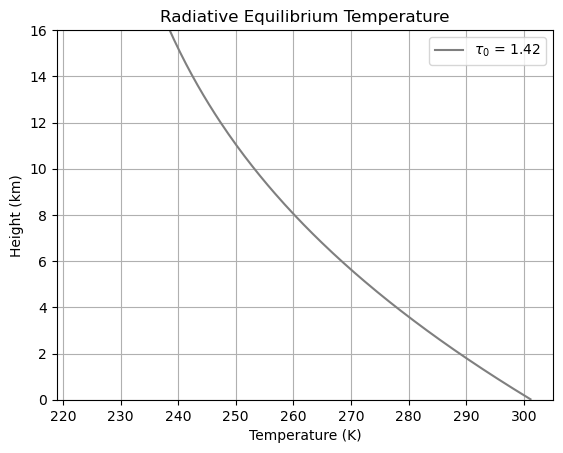

In [455]:
line_label = r"$\tau_0$ = " + str(tau1xCO2)
color = "tab:gray"
fig, ax = plt.subplots()
ax.plot(Ta_rad1xCO2_layers, z_layers / 1000.0, color=color, label=line_label)
ax.set_ylim(0, 16)
ax.set(
    title="Radiative Equilibrium Temperature",
    xlabel="Temperature (K)",
    ylabel="Height (km)",
)
ax.legend()
ax.grid()

### Calculate dry static energy for radiative equlibrium conditions.

In [456]:
s_rad1xCO2_layers = dry_static_energy(Ta_rad1xCO2_layers, z_layers)

### Plot how radiative equilibrium dry static energy varies with height.

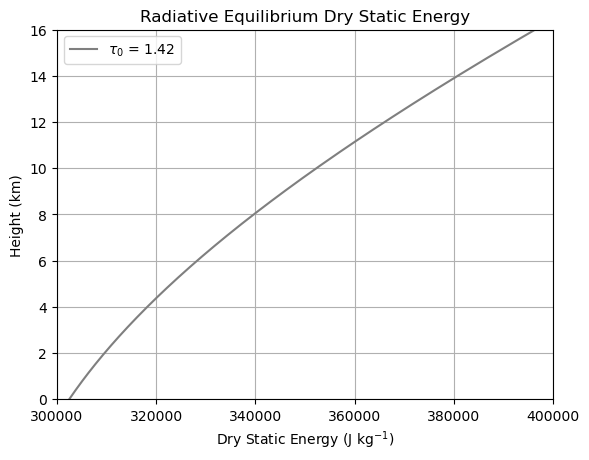

In [457]:
line_label = r"$\tau_0$ = " + str(tau1xCO2)
color = "tab:gray"
fig, ax = plt.subplots()
ax.plot(s_rad1xCO2_layers, z_layers / 1000.0, color=color, label=line_label)
ax.set_xlim(300000, 400000)
ax.set_ylim(0, 16)
ax.set(
    title="Radiative Equilibrium Dry Static Energy",
    xlabel="Dry Static Energy (J kg$^{-1}$)",
    ylabel="Height (km)",
)
ax.legend()
ax.grid()

### Define function to calculate temperature 2 m above the surface by extrapolating from lowest layer temperature.
- First input parameter is temperature of the lowest layer.
- Second input parameter is the height of the center of the lowest layer.
- Layer temperature is assumed to occur at the layer midpoint.
- Lapse rate is assumed to be dry adiabtic.

In [458]:
def temperature_at_2m(T1, z1):
    GammaD = 0.00977  # dry adiabatic lapse rate (units K/m)
    T2m = T1 + GammaD * (z1 - 2.0)  # calculate surface air temperature at 2 m
    return T2m  # return surface air temperature at 2m

### Calculate temperature 2 m above the surface for radiative equilibrium by extrapolating from lowest layer temperature.


In [459]:
T2m_rad1xCO2 = temperature_at_2m(Ta_rad1xCO2_layers[0], z_layers[0])
print(
    f"Radiative equilibrium surface air temperature = {T2m_rad1xCO2:.2f} for tau0 = {tau1xCO2}"
)
print(
    "Difference between radiative equilibrium surface temperature and "
    + f"surface air temperature = {Ts_rad1xCO2-T2m_rad1xCO2:.2f} for tau0 = {tau1xCO2}"
)

Radiative equilibrium surface air temperature = 301.32 for tau0 = 1.42
Difference between radiative equilibrium surface temperature and surface air temperature = 20.73 for tau0 = 1.42


### Define function to calculate sensible heat flux.
- First input parameter is surface temperature.
- Second input parameter is surface air temperature.
- Third input parameter is wind speed.
- Output is the sensible heat flux (units W m<sup>-2</sup>).
- Flux is defined positive upward.
- Specific heat for dry air is used.
- Surface air density is assumed to be 1.2 kg per cubic meter.
- The exchange coefficient is assumed to be 10<sup>-3</sup>.

In [460]:
def sensible_heat_flux(Ts, T2m, V0):
    C_SH = 0.001  # exchange coefficient
    c_p = 1004.0  # specific heat of air at constant pressure
    rho = 1.2  # surface air density (kg per cubic meter)
    F_SH = C_SH * c_p * rho * V0 * (Ts - T2m)  # sensible heat flux
    return F_SH

### Calculate sensible heat flux for radiative equilibrium surface temperature and surface air temperature.
- Flux is defined positive upward.

In [461]:
F_SH_rad1xCO2 = sensible_heat_flux(Ts_rad1xCO2, T2m_rad1xCO2, V0)
print(
    f"Sensible heat flux for radiative equilibrium temperatures = {F_SH_rad1xCO2:.2f}"
    + f" for tau0 = {tau1xCO2} and V0 = {V0}"
)

Sensible heat flux for radiative equilibrium temperatures = 124.86 for tau0 = 1.42 and V0 = 5.0


### Calculate the rate of temperature change in the lowest layer of the atmosphere due to sensible heat flux.
- This is done for radiative equilibrium surface temperature and surface air temperature.
- Flux is defined positive upward.
- Units are K per day.

In [462]:
dTa1dt_rad1xCO2_SH = g0 * F_SH_rad1xCO2 / (c_p * del_p)
dTa1dt_rad1xCO2_SH *= 60.0 * 60.0 * 24.0
print(
    "Rate of change of temperature in bottom layer due to sensible heat flux "
    + f"at radiative equilibrium temperatures = {dTa1dt_rad1xCO2_SH:.2f}"
    + f" for tau0 = {tau1xCO2} and V0 = {V0}"
)

Rate of change of temperature in bottom layer due to sensible heat flux at radiative equilibrium temperatures = 210.81 for tau0 = 1.42 and V0 = 5.0


### Define function to carry out dry convective adjustment via upward buoyancy.
- First input parameter is an array of dry static energy.
- Second input parameter is an array of layer center heights.
- Third input parameter is sensible heat flux.
- Fourth input parameter is the time increment in (units days).
- Fifth input parameter is the thickness of each layer in pressure coordinates (units Pa).
- Output is an array of dry static energy after dry convective adjustment arising from sensible heat flux.
- Flux is defined as positive upward.
- Instability is defined as decreasing dry static energy with height anywhere in profile.
- Energy from sensible heat flux is added to an increasing number of layers starting at the bottom of the atmosphere.
- The addition of energy is iterated until the atmosphere is no longer unstable.

In [463]:
def dry_convective_buoyancy_up(s_layers, z_layers, F_SH, del_t, del_p):
    g0 = 9.81  # gravitational acceleration
    s_layers_dry = copy.deepcopy(s_layers)  # initial energy for dry convective
    dSH = F_SH * 60.0 * 60.0 * 24.0 * del_t  # sensible heat energy increment
    dSH_single = dSH * g0 / del_p  # convert to J per kg for a single layer
    N = 1  # number of layers to convectively adjust from bottom upward
    unstable = True  # flag indicating instability
    while unstable:  # iterate as long as instability exists
        dSH_N = dSH_single / N  # divide sensible heat over N layers
        s_bottom_layers = np.average(
            s_layers[0:N]
        )  # convective mixing averages over layers
        s_layers_dry[0:N] = (
            s_bottom_layers + dSH_N
        )  # add sensible heat to bottom layers
        s_layers_dry[N:] = s_layers[N:]  # keep higher layers the same
        s_layers_diff = np.diff(s_layers_dry)  # difference between adjacent layers
        if np.any(s_layers_diff < 0):  # check if unstable (negative difference)
            N += 1  # if so, add another layer to stack
        else:  # otherwise
            unstable = False  # mark as stable
    return s_layers_dry  # return radiative-dry convective profile

### Define function to calculate radiative-dry convective equlilibrium surface and atmospheric temperature.
- First input parameter is an initial surface temperature.
- Second input parameter is an array of initial temperature at each atmospheric level.
- Third input parameter is the time increment in (units days).
- Fourth input parameter is the thickness of each layer in pressure coordinates (units Pa).
- Fifth input parameter is an array of emissivity of every atmospheric layer.
- Sixth input parameter is a 2-D array of transmission from every level to every level.
- Seventh input parameter is the value of the downward solar radiation flux absorbed by the surface.
- Eighth input parameter is an array the heights of layer centers.
- Ninth input parameter surface wind speed.
- Output is the surface temperature and an array of atmospheric temperature at radiative-dry convective equlilibrium.
- Flux is defined as positive upward and negative downward.
- Temperature is iterated until the magnitude of net energy flux at the surface and top of atmosphere is less than 0.1 W per square meter.
- Surface air temperature for sensible heat flux calculation is extrapolated from temperature of lowest atmospheric layer assuming a dry adiabatic lapse rate and that the layer temperature occurs at the layer midpoint.
- Sensible heat flux is added to atmosphere consistent with dry convective adjustment

In [464]:
def radiative_dry_convective_equilibrium_temperature(
    Ts,
    T_layers,
    del_t,
    del_p,
    emissivity_layers,
    trans_levels_to_levels,
    F_SW,
    z_layers,
    V0,
):
    T_layers_copy = copy.deepcopy(T_layers)  # avoid mutating temperature profile
    Ts_copy = copy.deepcopy(Ts)  # avoid mutating surface temperature
    max_F = 1.0  # max net energy flux at surface or TOA
    iteration_counter = 0  # counts number of iterations
    iteration_threshold = 0.1  # end iteration if max increment smaller
    while max_F > iteration_threshold:
        F_LW_levels = net_terrestrial_flux_at_all_levels(  # calculate net terrestrial
            Ts_copy,
            T_layers_copy,  # radiation flux at all levels
            emissivity_layers,
            trans_levels_to_levels,
        )
        F_div_layers = flux_divergence(F_LW_levels, del_p)  # divergence of net flux
        s_layers = dry_static_energy(
            T_layers_copy, z_layers  # calculate dry static energy from
        )  # previous profile of temperature
        dsdt_layers = rate_of_energy_change(  # rate of dry static energy change
            F_div_layers
        )  # due to radiative divergence
        ds_layers = dsdt_layers * del_t  # dry static energy change increment
        s_layers_rad = s_layers + ds_layers  # new dry static energy after radiation
        T2m = temperature_at_2m(
            T_layers_copy[0], z_layers[0]  # calculate air temperature at 2 m
        )  # (from old dry static energy)
        F_SH = sensible_heat_flux(Ts_copy, T2m, V0)  # calculate sensible heat flux
        s_layers_rad_dry = (
            dry_convective_buoyancy_up(  # add sensible heat to bottom layer
                s_layers_rad,
                z_layers,  # of atmosphere that undergoes
                F_SH,
                del_t,
                del_p,
            )
        )  # dry convective adjustment
        T_layers_copy = (
            T_from_dry_static_energy(  # get temperature from dry static energy
                s_layers_rad_dry, z_layers  # after radiation, sensible heat flux
            )
        )  # and dry convective adjustment
        dTsdt = rate_of_surface_temperature_change(  # rate of surface T change
            F_SW + F_LW_levels[0] + F_SH
        )
        dTs = dTsdt * del_t  # surface T change increment
        Ts_copy += dTs  # new surface temperature
        max_F = np.amax(  # maximum of either
            [
                np.abs(F_SW + F_LW_levels[0] + F_SH),  # net energy flux at surface
                np.abs(F_SW + F_LW_levels[-1]),
            ]
        )  # or net energy flux at TOA
        iteration_counter += 1
        if iteration_counter % 10 == 0:
            print("Converging...")
    print("Done!")
    return Ts_copy, T_layers_copy  # radiative-dry convective equilibrium T

### Calculate radiative-dry-convective equilibrium surface and atmospheric temperature.

In [465]:
Ts_rad_dry1xCO2, Ta_rad_dry1xCO2_layers = (
    radiative_dry_convective_equilibrium_temperature(
        Ts_rad1xCO2,
        Ta_rad1xCO2_layers,
        del_t,
        del_p,
        emissivity1xCO2_layers,
        trans1xCO2_levels_to_levels,
        F_SW,
        z_layers,
        V0,
    )
)

Converging...
Done!


### Print radiative-dry-convective equilibrium surface temperature.

In [466]:
print(
    f"Radiative-dry convective equilibrium surface temperature = {Ts_rad_dry1xCO2:.2f} "
    + f"for tau0 = {tau1xCO2} and V0 = {V0}"
)

Radiative-dry convective equilibrium surface temperature = 318.38 for tau0 = 1.42 and V0 = 5.0


### Plot how radiative-dry-convective equilibrium atmospheric temperature varies with height.

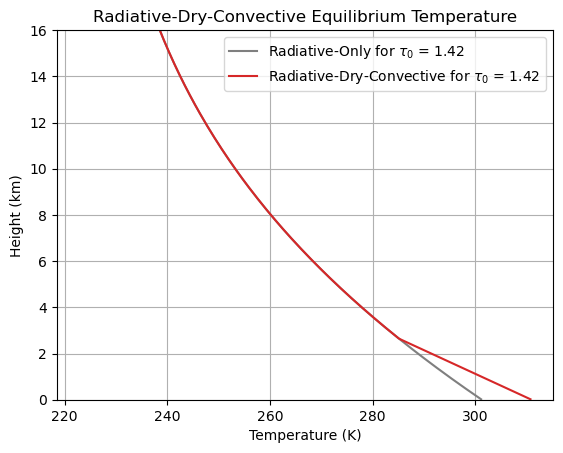

In [467]:
fig, ax = plt.subplots()
line_label = r"Radiative-Only for $\tau_0$ = " + str(tau1xCO2)
color = "tab:gray"
ax.plot(Ta_rad1xCO2_layers, z_layers / 1000.0, color=color, label=line_label)
line_label = r"Radiative-Dry-Convective for $\tau_0$ = " + str(tau1xCO2)
color = "tab:red"
ax.plot(Ta_rad_dry1xCO2_layers, z_layers / 1000.0, color=color, label=line_label)
ax.set_ylim(0, 16)
ax.set(
    title="Radiative-Dry-Convective Equilibrium Temperature",
    xlabel="Temperature (K)",
    ylabel="Height (km)",
)
ax.legend()
ax.grid()

### Calculate dry static energy for radiative-dry-convective equlibrium conditions.

In [468]:
s_rad_dry1xCO2_layers = dry_static_energy(Ta_rad_dry1xCO2_layers, z_layers)

### Plot how radiative-dry-convective equilibrium dry static energy varies with height.

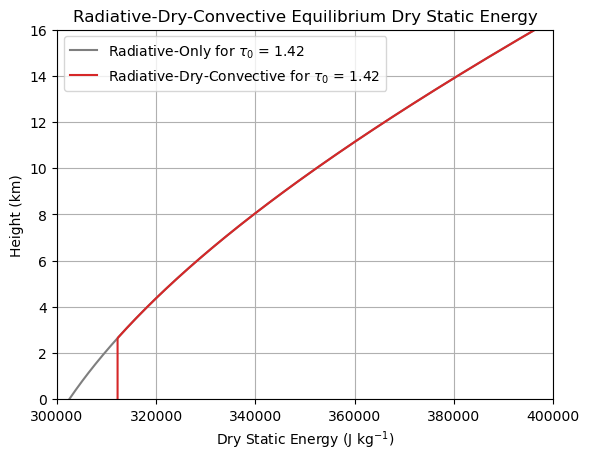

In [469]:
fig, ax = plt.subplots()
line_label = r"Radiative-Only for $\tau_0$ = " + str(tau1xCO2)
color = "tab:gray"
ax.plot(s_rad1xCO2_layers, z_layers / 1000.0, color=color, label=line_label)
line_label = r"Radiative-Dry-Convective for $\tau_0$ = " + str(tau1xCO2)
color = "tab:red"
ax.plot(s_rad_dry1xCO2_layers, z_layers / 1000.0, color=color, label=line_label)
ax.set_xlim(300000, 400000)
ax.set_ylim(0, 16)
ax.set(
    title="Radiative-Dry-Convective Equilibrium Dry Static Energy",
    xlabel="Dry Static Energy (J kg$^{-1}$)",
    ylabel="Height (km)",
)
ax.legend()
ax.grid()

### Calculate temperature 2 m above the surface for radiative-dry-convective equilibrium by extrapolating from lowest layer temperature.


In [470]:
T2m_rad_dry1xCO2 = temperature_at_2m(Ta_rad_dry1xCO2_layers[0], z_layers[0])
print(
    f"Radiative-dry-convective equilibrium surface air temperature = {T2m_rad_dry1xCO2:.2f} "
    + f"for tau0 = {tau1xCO2}"
)
print(
    "Difference between radiative-dry-convective equilibrium surface temperature and "
)
print(
    f"surface air temperature = {Ts_rad_dry1xCO2-T2m_rad_dry1xCO2:.2f} for tau0 = {tau1xCO2}"
)

Radiative-dry-convective equilibrium surface air temperature = 310.94 for tau0 = 1.42
Difference between radiative-dry-convective equilibrium surface temperature and 
surface air temperature = 7.44 for tau0 = 1.42


### Calculate sensible heat flux for radiative equilibrium surface temperature and surface air temperature.
- Flux is defined positive upward.

In [471]:
F_SH_rad_dry1xCO2 = sensible_heat_flux(Ts_rad_dry1xCO2, T2m_rad_dry1xCO2, V0)
print(
    "Sensible heat flux for radiative-dry-convective equilibrium temperatures = "
    + f"{F_SH_rad_dry1xCO2:.2f}"
)
print(f"for tau0 = {tau1xCO2} and V0 = {V0}")

Sensible heat flux for radiative-dry-convective equilibrium temperatures = 44.82
for tau0 = 1.42 and V0 = 5.0


### Define function to calculate saturation mixing ratio.
- First input parameter is temperature.
- Second input parameter is pressure.
- Output is the saturation mixing ratio.
- Saturation mixing ratio becomes larger at top of atmosphere because pressure goes to zero, so for layers above the saturation mixing ratio minimum value in profile to the minimum value.

In [472]:
def saturation_mixing_ratio(T, p):
    L = 2.5e6  # latent heat of vaporization
    Rv = 461.0  # gas constant for water vapor
    esat_ref = 611  # saturation pressure at reference temperature (units Pa)
    T_ref = 273  # reference temperature
    epsilon = 0.622  # ratio of water vapor to dry air molecular weight
    esat = esat_ref * np.exp(  # calculate saturation vapor pressure
        (L / Rv) * ((1.0 / T_ref) - (1 / T))
    )
    esat = np.clip(  # limit the saturation vapor pressure to be less than
        esat, 0.0, p / (1 + epsilon)
    )  # a fraction of atmospheric pressure (qsat < 1)
    qsat = epsilon * esat / (p - esat)  # calculate saturation mixing ratio
    if np.any(p < 10000.0):  # if pressure is less than 100 hPa
        if np.ndim(p) == 0:  # scalar/0d array: assign directly
            qsat = 0.0015
        else:
            p_index = np.where(p < 10000.0)  # find where pressure is less than 100 hPa
            if np.size(p_index) > 1:
                qsat[p_index] = 0.0015  # set to small constant in stratosphere
            else:
                qsat = 0.0015
    return qsat  # return saturation mixing ratio

### Define function to calculate latent heat flux.
- First input parameter is surface temperature.
- Second input parameter is surface air temperature.
- Third input parameter is surface pressure.
- Fourth input parameter is surface wind speed.
- Fifth input parameter is surface air relative humidity.
- Output is the sensible heat flux (units W m<sup>-2</sup>).
- The surface is assumed to be water (air at saturation).
- Flux is defined positive upward.
- Specific heat for dry air is used.
- Surface air density is assumed to be 1.2 kg per cubic meter.
- The exchange coefficient is assumed to be 10<sup>-3</sup>.

In [473]:
def latent_heat_flux(Ts, T2m, p0, V0, RH0):
    C_LH = 0.001  # exchange coefficient
    rho = 1.2  # surface air density (kg per cubic meter)
    qs = saturation_mixing_ratio(Ts, p0)  # get surface mixing ratio (assume saturated)
    q2m = RH0 * saturation_mixing_ratio(T2m, p0)  # get mixing ratio at 2m
    F_LH = C_LH * L * rho * V0 * (qs - q2m)  # calculate latent heat flux
    return F_LH  # return latent heat flux

### Calculate latent heat flux for radiative-dry-convective equilibrium surface temperature and surface air temperature.
- Flux is defined positive upward.

In [474]:
F_LH_rad_dry1xCO2 = latent_heat_flux(Ts_rad_dry1xCO2, T2m_rad_dry1xCO2, p0, V0, RH0)
print(
    "Latent heat flux for radiative-dry-convective equilibrium temperatures = "
    + f"{F_LH_rad_dry1xCO2:.2f}"
)
print(f" for tau0 = {tau1xCO2} and V0 = {V0} and RH0 = {RH0}")

Latent heat flux for radiative-dry-convective equilibrium temperatures = 526.36
 for tau0 = 1.42 and V0 = 5.0 and RH0 = 0.8


### Calculate the rate of temperature change in the lowest layer of the atmosphere due to latent heat flux.
- This is done for radiative-dry-convective equilibrium surface temperature and surface air temperature.
- Flux is defined positive upward.
- Units are K per day.

In [475]:
dTa1dt_rad_dry1xCO2_LH = g0 * F_LH_rad_dry1xCO2 / (c_p * del_p)
dTa1dt_rad_dry1xCO2_LH *= 60.0 * 60.0 * 24.0
print(
    "Rate of change of temperature in bottom layer due to latent heat flux "
    + f"at radiative-dry-convective equilibrium temperatures = {dTa1dt_rad_dry1xCO2_LH:.2f}"
    + f" for tau0 = {tau1xCO2} and V0 = {V0} and RH0 = {RH0}"
)

Rate of change of temperature in bottom layer due to latent heat flux at radiative-dry-convective equilibrium temperatures = 888.72 for tau0 = 1.42 and V0 = 5.0 and RH0 = 0.8


### Define function to calculate saturated moist static energy.
- First input parameter is an array of temperature of each atmospheric layer.
- Second input parameter is an array of the pressure at each layer center.
- Third input parameter is an array of the height at each layer center.
- Output is the saturated moist static energy at each layer center.
- Layer temperature is assumed to occur at the layer midpoint.
- Specific heat for dry air is used.
- Air is assumed to be saturated.

In [476]:
def saturated_moist_static_energy(T_layers, p_layers, z_layers):
    g0 = 9.81  # gravitational acceleration
    c_p = 1004.0  # specific heat of air at constant pressure
    L = 2.5e6  # latent heat of vaporization
    qsat_layers = saturation_mixing_ratio(
        T_layers, p_layers
    )  # calculate saturation mixing ratio
    hsat_layers = (
        g0 * z_layers + c_p * T_layers + L * qsat_layers
    )  # calculate moist static energy
    return hsat_layers  # return moist static energy

### Calculate saturated moist static energy.


In [477]:
hsat_rad_dry1xCO2_layers = saturated_moist_static_energy(
    Ta_rad_dry1xCO2_layers, p_layers, z_layers
)

### Plot how radiative-dry-convective equilibrium saturated moist static energy varies with height.

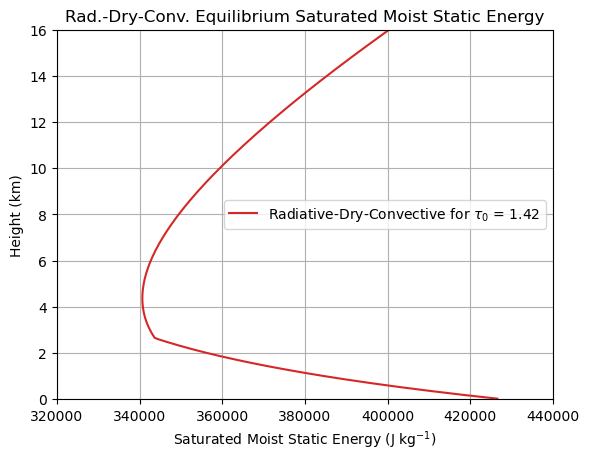

In [478]:
line_label = r"Radiative-Dry-Convective for $\tau_0$ = " + str(tau1xCO2)
color = "tab:red"
fig, ax = plt.subplots()
ax.plot(hsat_rad_dry1xCO2_layers, z_layers / 1000.0, color=color, label=line_label)
ax.set_xlim(320000, 440000)
ax.set_ylim(0, 16)
ax.set(
    title="Rad.-Dry-Conv. Equilibrium Saturated Moist Static Energy",
    xlabel="Saturated Moist Static Energy (J kg$^{-1}$)",
    ylabel="Height (km)",
)
ax.legend()
ax.grid()

### Define function to calculate temperature from saturated moist static energy.
- First input parameter is an array of saturated moist static energy of each atmospheric layer.
- Second input parameter is an array of the pressure at each layer center.
- Third input parameter is an array of the height at each layer center.
- Output is the temperature of each layer center.
- Layer temperature is assumed to occur at the layer midpoint.
- Specific heat for dry air is used.
- Air is assumed to be saturated.
- Iteration is used to find temperature that results in saturated moist static energy matching the input saturated moist static energy.

In [479]:
def T_from_saturated_moist_static_energy(hsat_layers, p_layers, z_layers):
    T_layers = T_from_dry_static_energy(
        hsat_layers, z_layers  # set initial temperature profile
    )  # according to dry static energy
    for l in range(0, hsat_layers.size):  # do this for each layer
        dT = 1.0  # max temperature increment
        iteration_threshold = 0.0001  # end iteration if max increment smaller
        while np.abs(dT) > iteration_threshold:
            new_hsat = (
                saturated_moist_static_energy(  # calculate new moist static energy
                    T_layers[l], p_layers[l], z_layers[l]
                )
            )
            dT = (hsat_layers[l] - new_hsat) / hsat_layers[
                l
            ]  # adjust by relative difference in MSE
            T_layers[l] += dT  # change temperature by increment
    return T_layers

### Define function to carry out moist convective adjustment via upward buoyancy.
- First input parameter is an array of saturated moist static energy.
- Second input parameter is an array of layer center pressures.
- Third input parameter is an array of layer center heights.
- Fourth input parameter is the sum of sensible and latent heat flux.
- Fifth input parameter is the time increment in (units days).
- Sixth input parameter is the thickness of each layer in pressure coordinates (units Pa).
- Output is an array of saturated moist static energy after moist convective adjustment arising from sensible and latent heat flux.
- Flux is defined as positive upward.
- Instability is defined as decreasing saturated moist static energy with height anywhere in profile.
- Energy from sensible and latent heat flux is added to an increasing number of layers starting at the bottom of the atmosphere.
- The addition of energy is iterated until the atmosphere is no longer unstable.
- The entire atmosphere is considered to be saturation.

In [480]:
def moist_convective_buoyancy_up(
    hsat_layers, p_layers, z_layers, F_SH_LH, del_t, del_p
):
    g0 = 9.81  # gravitational acceleration
    hsat_layers_conv = copy.deepcopy(hsat_layers)  # initial energy for moist convective
    dSH_LH = F_SH_LH * 60.0 * 60.0 * 24.0 * del_t  # sensible + latent energy increment
    dSH_LH_single = dSH_LH * g0 / del_p  # convert to J per kg for a single layer
    N = 1  # number of layers to convectively adjust from bottom upward
    unstable = True  # flag indicating instability
    while unstable:  # iterate as long as instability exists
        dSH_LH_N = dSH_LH_single / N  # divide sensible + latent over N layers
        hsat_bottom_layers = np.average(  # convective mixing averages over layers
            hsat_layers[0:N]
        )
        hsat_layers_conv[0:N] = (  # add sensible and latent heat
            hsat_bottom_layers + dSH_LH_N
        )  # to bottom layers
        hsat_layers_conv[N:] = hsat_layers[N:]  # keep higher layers the same
        hsat_layers_diff = np.diff(
            hsat_layers_conv
        )  # difference between adjacent layers
        if np.any(hsat_layers_diff < 0):  # check if unstable (negative difference)
            N += 1  # if so, add another layer to stack
        else:  # otherwise
            unstable = False  # mark as stable
    return hsat_layers_conv  # return radiative-convective profile

### Define function to calculate radiative-convective equlilibrium surface and atmospheric temperature.
- First input parameter is an initial surface temperature.
- Second input parameter is an array of initial temperature at each atmospheric level.
- Third input parameter is the time increment in (units days).
- Fourth input parameter is the thickness of each layer in pressure coordinates (units Pa).
- Fifth input parameter is an array of emissivity of every atmospheric layer.
- Sixth input parameter is a 2-D array of transmission from every level to every level.
- Seventh input parameter is the value of the downward solar radiation flux absorbed by the surface.
- Eigthh input parameter is an array of the pressures at layer centers.
- Ninth input parameter is an array the heights at layer centers.
- Tenth input parameter is surface pressure.
- Eleventh input parameter is surface wind speed.
- Twelfth input parameter is surface air relative humidity.
- Output is the surface temperature and an array of atmospheric temperature at radiative-convective equlilibrium.
- Flux is defined as positive upward and negative downward.
- Temperature is iterated until the magnitude of net energy flux at the surface and top of atmosphere is less than 0.5 W per square meter.
- Surface air temperature for sensible heat flux and latent heat flux calculations is extrapolated from temperature of lowest atmospheric layer assuming a dry adiabatic lapse rate and that the layer temperature occurs at the layer midpoint.
- Sensible heat flux and latent heat flux are added to atmosphere consistent with moist convective adjustment
- All layers of the atmosphere are assumed to be saturated for moist convective adjustment.

In [481]:
def radiative_convective_equilibrium_temperature(
    Ts,
    T_layers,
    del_t,
    del_p,
    emissivity_layers,
    trans_levels_to_levels,
    F_SW,
    p_layers,
    z_layers,
    p0,
    V0,
    RH0,
):
    T_layers_copy = copy.deepcopy(T_layers)  # avoid mutating temperature profile
    Ts_copy = copy.deepcopy(Ts)  # avoid mutating surface temperature
    dF = 1.0  # energy flux imbalance
    iteration_counter = 0  # counts number of iterations
    iteration_threshold = 0.5  # end iteration if imbalance smaller
    while dF > iteration_threshold:
        F_LW_levels = net_terrestrial_flux_at_all_levels(  # calculate net terrestrial
            Ts_copy,
            T_layers_copy,  # radiation flux at all levels
            emissivity_layers,
            trans_levels_to_levels,
        )
        F_div_layers = flux_divergence(F_LW_levels, del_p)  # divergence of net flux
        hsat_layers = (
            saturated_moist_static_energy(  # calculate saturated moist static energy
                T_layers_copy,  # from previous profile of temperature
                p_layers,
                z_layers,
            )
        )
        dhsatdt_layers = (
            rate_of_energy_change(  # rate of sat. moist static energy change
                F_div_layers
            )
        )  # due to radiative divergence
        dhsat_layers = dhsatdt_layers * del_t  # moist static energy change increment
        hsat_layers_rad = (
            hsat_layers + dhsat_layers
        )  # new moist static energy after radiation
        T2m = temperature_at_2m(
            T_layers_copy[0], z_layers[0]  # calculate air temperature at 2 m
        )  # (from old moist static energy)
        F_SH = sensible_heat_flux(Ts_copy, T2m, V0)  # calculate sensible heat flux
        F_LH = latent_heat_flux(Ts_copy, T2m, p0, V0, RH0)  # calculate latent heat flux
        F_SH_LH = F_SH + F_LH  # combine sensible and latent heat flux
        hsat_layers_rad_conv = (
            moist_convective_buoyancy_up(  # add sensible + latent to bottom layer
                hsat_layers_rad,
                p_layers,  # of atmosphere that undergoes
                z_layers,
                F_SH_LH,
                del_t,
                del_p,
            )
        )  # moist convective adjustment
        T_layers_copy = T_from_saturated_moist_static_energy(  # get temperature from moist static energy
            hsat_layers_rad_conv,  # after radiation, sensible + latent
            p_layers,
            z_layers,
        )  # and moist convective adjustment
        dTsdt = rate_of_surface_temperature_change(  # rate of surface T change
            F_SW + F_LW_levels[0] + F_SH_LH
        )
        dTs = dTsdt * del_t  # surface T change increment
        Ts_copy += dTs  # new surface temperature
        dF = np.amax(  # maximum of either
            [
                np.abs(F_SW + F_LW_levels[0] + F_SH_LH),  # net energy flux at surface
                np.abs(F_SW + F_LW_levels[-1]),
            ]
        )  # or net energy flux at TOA
        iteration_counter += 1
        if iteration_counter % 1 == 0:
            print("Converging...")
    print("Done!")
    return Ts_copy, T_layers_copy  # radiative-convective equilibrium T

### Calculate radiative-convective equilibrium surface and atmospheric temperature.
- This will be done for 1xCO2 conditions.

In [482]:
Ts_rad_conv1xCO2, Ta_rad_conv1xCO2_layers = (
    radiative_convective_equilibrium_temperature(
        Ts_rad1xCO2,
        Ta_rad1xCO2_layers,
        del_t,
        del_p,
        emissivity1xCO2_layers,
        trans1xCO2_levels_to_levels,
        F_SW,
        p_layers,
        z_layers,
        p0,
        V0,
        RH0,
    )
)

Converging...
Converging...
Converging...
Converging...
Converging...
Converging...
Converging...
Converging...
Converging...
Converging...
Converging...
Converging...
Converging...
Converging...
Converging...
Converging...
Converging...
Converging...
Converging...
Converging...
Converging...
Converging...
Converging...
Converging...
Converging...
Converging...
Converging...
Converging...
Converging...
Converging...
Converging...
Converging...
Converging...
Converging...
Converging...
Converging...
Converging...
Converging...
Converging...
Converging...
Converging...
Converging...
Converging...
Converging...
Converging...
Converging...
Converging...
Converging...
Converging...
Converging...
Converging...
Converging...
Converging...
Converging...
Converging...
Converging...
Done!


### Print radiative-convective equilibrium surface temperature.

In [483]:
print(
    f"Radiative-convective equilibrium surface temperature = {Ts_rad_conv1xCO2:.2f} "
    + f"for tau0 = {tau1xCO2} and V0 = {V0} and RH0 = {RH0}"
)

Radiative-convective equilibrium surface temperature = 303.16 for tau0 = 1.42 and V0 = 5.0 and RH0 = 0.8


### Calculate temperature 2 m above the surface for radiative-convective equilibrium by extrapolating from lowest layer temperature.


In [484]:
T2m_rad_conv1xCO2 = temperature_at_2m(Ta_rad_conv1xCO2_layers[0], z_layers[0])
print(
    f"Radiative-convective equilibrium surface air temperature = {T2m_rad_conv1xCO2:.2f} "
    + f"for tau0 = {tau1xCO2}"
)
print("Difference between radiative-convective equilibrium surface temperature and ")
print(
    f"surface air temperature = {Ts_rad_conv1xCO2-T2m_rad_conv1xCO2:.2f} for tau0 = {tau1xCO2}"
)

Radiative-convective equilibrium surface air temperature = 300.76 for tau0 = 1.42
Difference between radiative-convective equilibrium surface temperature and 
surface air temperature = 2.40 for tau0 = 1.42


### Plot how radiative-convective equilibrium atmospheric temperature varies with height.

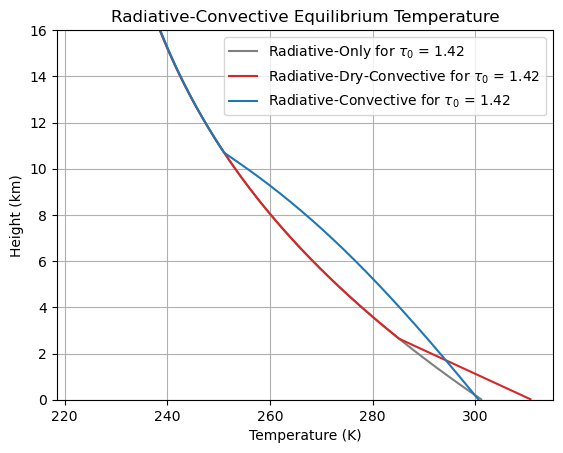

In [485]:
fig, ax = plt.subplots()
line_label = r"Radiative-Only for $\tau_0$ = " + str(tau1xCO2)
color = "tab:gray"
ax.plot(Ta_rad1xCO2_layers, z_layers / 1000.0, color=color, label=line_label)
line_label = r"Radiative-Dry-Convective for $\tau_0$ = " + str(tau1xCO2)
color = "tab:red"
ax.plot(Ta_rad_dry1xCO2_layers, z_layers / 1000.0, color=color, label=line_label)
line_label = r"Radiative-Convective for $\tau_0$ = " + str(tau1xCO2)
color = "tab:blue"
ax.plot(Ta_rad_conv1xCO2_layers, z_layers / 1000.0, color=color, label=line_label)
ax.set_ylim(0, 16)
ax.set(
    title="Radiative-Convective Equilibrium Temperature",
    xlabel="Temperature (K)",
    ylabel="Height (km)",
)
ax.legend()
ax.grid()

### Calculate dry static energy for radiative-convective equlibrium conditions.

In [486]:
s_rad_conv1xCO2_layers = dry_static_energy(Ta_rad_conv1xCO2_layers, z_layers)

### Plot how radiative-convective equilibrium dry static energy varies with height.

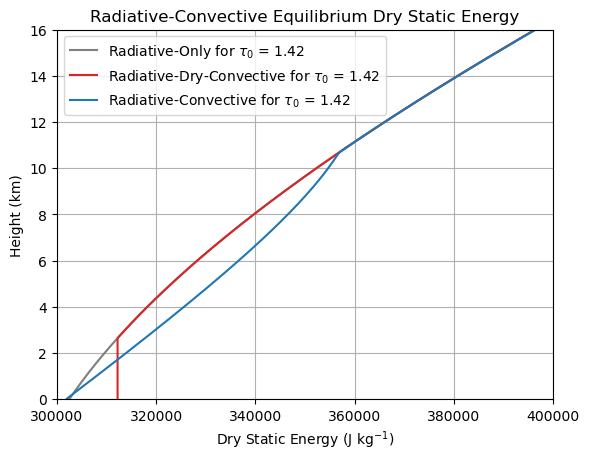

In [487]:
fig, ax = plt.subplots()
line_label = r"Radiative-Only for $\tau_0$ = " + str(tau1xCO2)
color = "tab:gray"
ax.plot(s_rad1xCO2_layers, z_layers / 1000.0, color=color, label=line_label)
line_label = r"Radiative-Dry-Convective for $\tau_0$ = " + str(tau1xCO2)
color = "tab:red"
ax.plot(s_rad_dry1xCO2_layers, z_layers / 1000.0, color=color, label=line_label)
line_label = r"Radiative-Convective for $\tau_0$ = " + str(tau1xCO2)
color = "tab:blue"
ax.plot(s_rad_conv1xCO2_layers, z_layers / 1000.0, color=color, label=line_label)
ax.set_xlim(300000, 400000)
ax.set_ylim(0, 16)
ax.set(
    title="Radiative-Convective Equilibrium Dry Static Energy",
    xlabel="Dry Static Energy (J kg$^{-1}$)",
    ylabel="Height (km)",
)
ax.legend()
ax.grid()

### Calculate saturated moist static energy.

In [488]:
hsat_rad1xCO2_layers = saturated_moist_static_energy(
    Ta_rad1xCO2_layers, p_layers, z_layers
)
hsat_rad_conv1xCO2_layers = saturated_moist_static_energy(
    Ta_rad_conv1xCO2_layers, p_layers, z_layers
)

### Plot how radiative-convective equilibrium saturated moist static energy varies with height.

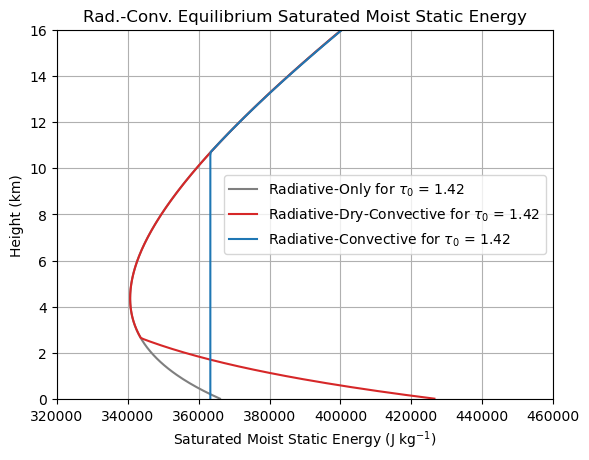

In [489]:
fig, ax = plt.subplots()
line_label = r"Radiative-Only for $\tau_0$ = " + str(tau1xCO2)
color = "tab:gray"
ax.plot(hsat_rad1xCO2_layers, z_layers / 1000.0, color=color, label=line_label)
line_label = r"Radiative-Dry-Convective for $\tau_0$ = " + str(tau1xCO2)
color = "tab:red"
ax.plot(hsat_rad_dry1xCO2_layers, z_layers / 1000.0, color=color, label=line_label)
line_label = r"Radiative-Convective for $\tau_0$ = " + str(tau1xCO2)
color = "tab:blue"
ax.plot(hsat_rad_conv1xCO2_layers, z_layers / 1000.0, color=color, label=line_label)
ax.set_xlim(320000, 460000)
ax.set_ylim(0, 16)
ax.set(
    title="Rad.-Conv. Equilibrium Saturated Moist Static Energy",
    xlabel="Saturated Moist Static Energy (J kg$^{-1}$)",
    ylabel="Height (km)",
)
ax.legend()
ax.grid()

### Calculate tropopause layer height and temperature.
- The tropopause is the highest layer that is convectively mixed.
- It is identified as the lowest layer for which saturated moist static energy increases by at least 100 J per kg from on layer to the next layer.

In [490]:
tropopause_index_1xCO2 = np.min(np.where(np.diff(hsat_rad_conv1xCO2_layers) > 100.0))
print(
    "Radiative-convective equilibrium tropopause height = "
    + f"{z_layers[tropopause_index_1xCO2]:.0f}"
)
print(f"for tau0 = {tau1xCO2} and V0 = {V0} and RH0 = {RH0}\n")
print(
    f"Radiative-convective equilibrium tropopause temperature = "
    + f"{Ta_rad_conv1xCO2_layers[tropopause_index_1xCO2]:.2f}"
)
print(f"for tau0 = {tau1xCO2} and V0 = {V0} and RH0 = {RH0}")

Radiative-convective equilibrium tropopause height = 10549
for tau0 = 1.42 and V0 = 5.0 and RH0 = 0.8

Radiative-convective equilibrium tropopause temperature = 251.98
for tau0 = 1.42 and V0 = 5.0 and RH0 = 0.8


### Calculate net terrestrial radiation flux for radiative-convective equilibrium surface temperature and surface air temperature.
- Flux is defined positive upward.

In [491]:
F_LW_rad_conv1xCO2_levels = net_terrestrial_flux_at_all_levels(
    Ts_rad_conv1xCO2,
    Ta_rad_conv1xCO2_layers,
    emissivity1xCO2_layers,
    trans1xCO2_levels_to_levels,
)
print("Net solar and terrestrial radiation flux at the surface")
print(
    "for radiative-convective equilibrium temperatures = "
    + f"{F_SW + F_LW_rad_conv1xCO2_levels[0]:.2f}"
)
print(f"for tau0 = {tau1xCO2} and V0 = {V0} and RH0 = {RH0}\n")
print(f"Net solar only = {F_SW:.2f}")
print(f"Net terrestrial only = {F_LW_rad_conv1xCO2_levels[0]:.2f}")

Net solar and terrestrial radiation flux at the surface
for radiative-convective equilibrium temperatures = -148.42
for tau0 = 1.42 and V0 = 5.0 and RH0 = 0.8

Net solar only = -280.00
Net terrestrial only = 131.58


### Calculate sensible heat flux for radiative-convective equilibrium surface temperature and surface air temperature.
- Flux is defined positive upward.

In [492]:
F_SH_rad_conv1xCO2 = sensible_heat_flux(Ts_rad_conv1xCO2, T2m_rad_conv1xCO2, V0)
print(
    "Sensible heat flux for radiative-convective equilibrium temperatures = "
    + f"{F_SH_rad_conv1xCO2:.2f}"
)
print(f"for tau0 = {tau1xCO2} and V0 = {V0}")

Sensible heat flux for radiative-convective equilibrium temperatures = 14.44
for tau0 = 1.42 and V0 = 5.0


### Calculate latent heat flux for radiative-convective equilibrium surface temperature and surface air temperature.
- Flux is defined positive upward.

In [493]:
F_LH_rad_conv1xCO2 = latent_heat_flux(Ts_rad_conv1xCO2, T2m_rad_conv1xCO2, p0, V0, RH0)
print(
    "Latent heat flux for radiative-convective equilibrium temperatures = "
    + f"{F_LH_rad_conv1xCO2:.2f}"
)
print(f" for tau0 = {tau1xCO2} and V0 = {V0} and RH0 = {RH0}")

Latent heat flux for radiative-convective equilibrium temperatures = 133.61
 for tau0 = 1.42 and V0 = 5.0 and RH0 = 0.8


### Calculate the average heating rate of the atmosphere caused by the latent heat of precipitation.
- Units K per day.

In [494]:
dTavglatentdt_rad_conv1xCO2 = g0 * F_LH_rad_conv1xCO2 / (p0 * c_p)
dTavglatentdt_rad_conv1xCO2 *= 60.0 * 60.0 * 24.0
print("Average atmospheric heating rate for latent heat from precipitation")
print(
    "for radiative-convective equilibrium temperatures = "
    + f"{dTavglatentdt_rad_conv1xCO2:.2f}\n"
)
dTavgsensibledt_rad_conv1xCO2 = g0 * F_SH_rad_conv1xCO2 / (p0 * c_p)
dTavgsensibledt_rad_conv1xCO2 *= 60.0 * 60.0 * 24.0
print("Average atmospheric heating rate for sensible heat")
print(
    "for radiative-convective equilibrium temperatures = "
    + f"{dTavgsensibledt_rad_conv1xCO2:.2f}"
)

Average atmospheric heating rate for latent heat from precipitation
for radiative-convective equilibrium temperatures = 1.13

Average atmospheric heating rate for sensible heat
for radiative-convective equilibrium temperatures = 0.12


### Plot how net solar and terrestrial radiation flux varies with height for radiative-convective equilibrium surface temperature and surface air temperature.
- Flux is defined positive upward.

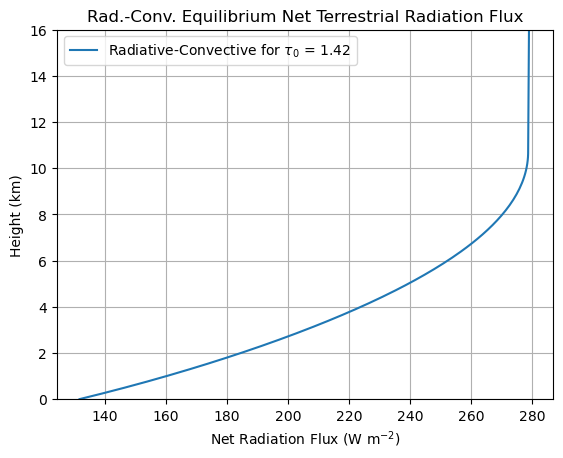

In [495]:
line_label = r"Radiative-Convective for $\tau_0$ = " + str(tau1xCO2)
color = "tab:blue"
fig, ax = plt.subplots()
ax.plot(
    F_LW_rad_conv1xCO2_levels[:-1], z_levels / 1000.0, color=color, label=line_label
)
ax.set_ylim(0, 16)
ax.set(
    title="Rad.-Conv. Equilibrium Net Terrestrial Radiation Flux",
    xlabel="Net Radiation Flux (W m$^{-2}$)",
    ylabel="Height (km)",
)
ax.legend()
ax.grid()

### Calculate net radiative cooling of the atmosphere for radiative-convective equilibrium surface temperature and surface air temperature.
- Flux is defined positive upward.
- Units K per day.

In [496]:
F_div_rad_conv1xCO2_layers = flux_divergence(F_LW_rad_conv1xCO2_levels, del_p)
dTadivdt_rad_conv1xCO2_layers = (
    rate_of_energy_change(F_div_rad_conv1xCO2_layers) * del_t / c_p
)

### Plot net radiative cooling of the atmosphere for radiative-convective equilibrium surface temperature and surface air temperature.
- Units K per day.

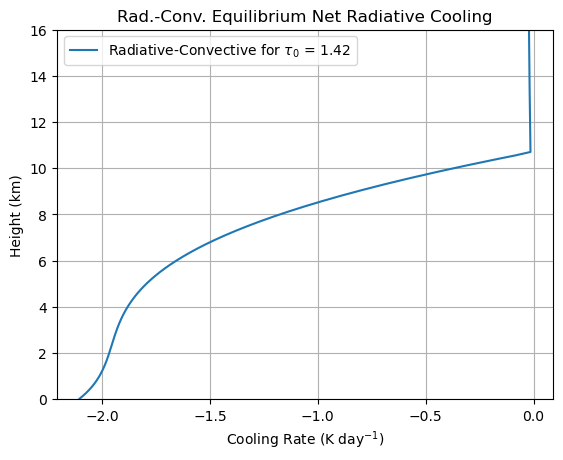

In [497]:
line_label = r"Radiative-Convective for $\tau_0$ = " + str(tau1xCO2)
color = "tab:blue"
fig, ax = plt.subplots()
ax.plot(dTadivdt_rad_conv1xCO2_layers, z_layers / 1000.0, color=color, label=line_label)
ax.set_ylim(0, 16)
ax.set(
    title="Rad.-Conv. Equilibrium Net Radiative Cooling",
    xlabel="Cooling Rate (K day$^{-1}$)",
    ylabel="Height (km)",
)
ax.legend()
ax.grid()

### Calculate the average radiative cooling rate of the atmosphere.
- Units K per day.

In [498]:
dTavgdivdt_rad_conv1xCO2 = np.average(dTadivdt_rad_conv1xCO2_layers)
print("Average atmospheric radiative cooling rate")
print(
    "for radiative-convective equilibrium temperatures = "
    + f"{dTavgdivdt_rad_conv1xCO2:.2f}"
)

Average atmospheric radiative cooling rate
for radiative-convective equilibrium temperatures = -1.25


### Calculate vertical velocity producing advection of dry static energy that balances divergence of net radiation flux.
- Flux is defined positive upward.
- Vertical gradient of dry static energy calculated via centered finite difference.
- Units m per day.

In [499]:
dsdz_rad_conv1xCO2_layers = (
    s_rad_conv1xCO2_layers[2:] - s_rad_conv1xCO2_layers[:-2]
) / (z_layers[2:] - z_layers[:-2])
w_rad_conv1xCO2_layers = (
    rate_of_energy_change(F_div_rad_conv1xCO2_layers[1:-1]) / dsdz_rad_conv1xCO2_layers
)

### Plot vertical velocity producing advection of dry static energy that balances divergence of net radiation flux.
- Flux is defined positive upward.
- Vertical gradient of dry static energy calculated via centered finite difference.
- Units m per day.

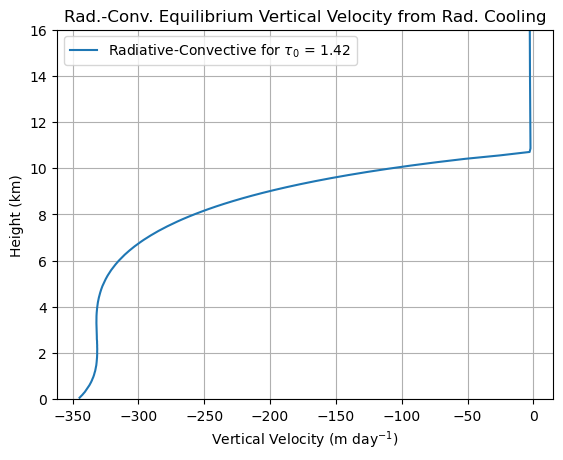

In [500]:
line_label = r"Radiative-Convective for $\tau_0$ = " + str(tau1xCO2)
color = "tab:blue"
fig, ax = plt.subplots()
ax.plot(w_rad_conv1xCO2_layers, z_layers[1:-1] / 1000.0, color=color, label=line_label)
ax.set_ylim(0, 16)
ax.set(
    title="Rad.-Conv. Equilibrium Vertical Velocity from Rad. Cooling",
    xlabel="Vertical Velocity (m day$^{-1}$)",
    ylabel="Height (km)",
)
ax.legend()
ax.grid()

### Calculate the precipitation rate from latent heat flux.
- Units mm per day.

In [501]:
P_rad_conv1xCO2 = F_LH_rad_conv1xCO2 / (L * rho_l)
P_rad_conv1xCO2 *= 1000.0 * 60.0 * 60.0 * 24.0
print(
    "Precipitation rate for radiative-convective equilibrium temperatures = "
    + f"{P_rad_conv1xCO2:.2f}"
)

Precipitation rate for radiative-convective equilibrium temperatures = 4.62


### Calculate the integrated water vapor in the atmospheric column.
- The atmosphere is assumed to be saturated.
- Units mm.

In [502]:
qsat_rad_conv1xCO2_layers = saturation_mixing_ratio(Ta_rad_conv1xCO2_layers, p_layers)
qavg = np.average(qsat_rad_conv1xCO2_layers)
IWV_rad_conv1xCO2 = qavg * p0 / (g0 * rho_l)
IWV_rad_conv1xCO2 *= 1000.0
print(
    "Integrated water vapor for radiative-convective equilibrium temperatures = "
    + f"{IWV_rad_conv1xCO2:.2f}"
)

Integrated water vapor for radiative-convective equilibrium temperatures = 117.40


### Calculate net flux from atmosphere and surface for 1xCO2 radiative-convective equilibrium temperature but 2xCO2 optical thickness.

In [503]:
F_LW_rad_conv1xCO2T_2xCO2_levels = net_terrestrial_flux_at_all_levels(
    Ts_rad_conv1xCO2,
    Ta_rad_conv1xCO2_layers,
    emissivity2xCO2_layers,
    trans2xCO2_levels_to_levels,
)

### Plot how change in net flux varies with pressure.
- Atmospheric and surface temperature correspond to radiative-convective equilibrium for 1xCO2.
- Emissivity and transmissivity correspond to 2xCO2.
- Flux is defined positive upward.

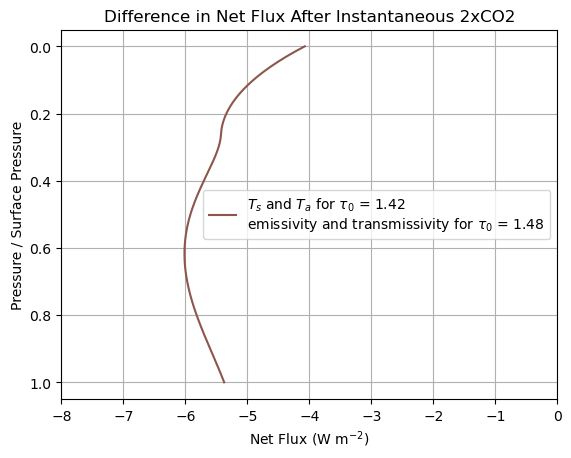

In [504]:
line_label = (
    r"$T_s$ and $T_a$ for $\tau_0$ = "
    + str(tau1xCO2)
    + "\n"
    + r"emissivity and transmissivity for $\tau_0$ = "
    + str(tau2xCO2)
)
color = "tab:brown"
fig, ax = plt.subplots()
ax.plot(
    F_LW_rad_conv1xCO2T_2xCO2_levels - F_LW_rad_conv1xCO2_levels,
    p_ratio_levels,
    color=color,
    label=line_label,
)
ax.invert_yaxis()
ax.set_xlim(-8, 0)
ax.set(
    title="Difference in Net Flux After Instantaneous 2xCO2",
    xlabel="Net Flux (W m$^{-2}$)",
    ylabel="Pressure / Surface Pressure",
)
ax.legend()
ax.grid()

### Calculate forcing from 2xCO2

In [505]:
dQ = -(F_LW_rad_conv1xCO2T_2xCO2_levels[-1] - F_LW_rad_conv1xCO2_levels[-1])
print("Forcing at TOA = " + f"{dQ:.2f} for p = 0")

Forcing at TOA = 4.07 for p = 0


### Calculate radiative-convective equilibrium surface and atmospheric temperature.
- This will be done for 2xCO2 conditions.

In [506]:
Ts_rad_conv2xCO2, Ta_rad_conv2xCO2_layers = (
    radiative_convective_equilibrium_temperature(
        Ts_rad_conv1xCO2,
        Ta_rad_conv1xCO2_layers,
        del_t,
        del_p,
        emissivity2xCO2_layers,
        trans2xCO2_levels_to_levels,
        F_SW,
        p_layers,
        z_layers,
        p0,
        V0,
        RH0,
    )
)

Converging...
Converging...
Converging...
Converging...
Converging...
Converging...
Converging...
Converging...
Converging...
Converging...
Converging...
Converging...
Converging...
Converging...
Converging...
Converging...
Converging...
Converging...
Converging...
Converging...
Converging...
Converging...
Converging...
Converging...
Converging...
Converging...
Converging...
Converging...
Converging...
Converging...
Converging...
Converging...
Converging...
Converging...
Converging...
Converging...
Converging...
Converging...
Converging...
Converging...
Converging...
Converging...
Converging...
Converging...
Converging...
Converging...
Converging...
Converging...
Converging...
Converging...
Converging...
Converging...
Converging...
Converging...
Converging...
Converging...
Converging...
Converging...
Converging...
Done!


### Print radiative equilibrium surface temperature.

In [507]:
print(
    "Radiative-convective equilibrium surface temperature ="
    + f" {Ts_rad_conv2xCO2:.2f} for tau0 = {tau2xCO2}"
)

Radiative-convective equilibrium surface temperature = 303.93 for tau0 = 1.48


### Calculate climate sensitivity parameter.
- $\lambda$<sub>R</sub> = $\Delta$T<sub>s</sub> / $\Delta$Q

In [508]:
lambdaR = (Ts_rad_conv2xCO2 - Ts_rad_conv1xCO2) / dQ
print(f"Climate sensitivty parameter = {lambdaR}")

Climate sensitivty parameter = 0.18864457022438028


### Calculate temperature 2 m above the surface for radiative-convective equilibrium by extrapolating from lowest layer temperature.


In [509]:
T2m_rad_conv2xCO2 = temperature_at_2m(Ta_rad_conv2xCO2_layers[0], z_layers[0])
print(
    f"Radiative-convective equilibrium surface air temperature = {T2m_rad_conv2xCO2:.2f} "
    + f"for tau0 = {tau2xCO2}"
)
print("Difference between radiative-convective equilibrium surface temperature and ")
print(
    f"surface air temperature = {Ts_rad_conv2xCO2-T2m_rad_conv2xCO2:.2f} for tau0 = {tau2xCO2}"
)

Radiative-convective equilibrium surface air temperature = 301.57 for tau0 = 1.48
Difference between radiative-convective equilibrium surface temperature and 
surface air temperature = 2.36 for tau0 = 1.48


### Plot how the change in radiative equilibrium atmospheric temperature varies with height.
- Do this for the change from 1xCO2 to 2xCO2.

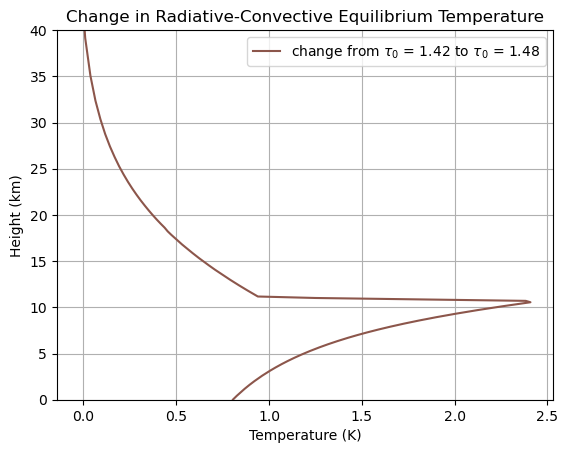

In [510]:
line_label = (
    r"change from $\tau_0$ = " + str(tau1xCO2) + r" to $\tau_0$ = " + str(tau2xCO2)
)
fig, ax = plt.subplots()
ax.plot(
    Ta_rad_conv2xCO2_layers - Ta_rad_conv1xCO2_layers,
    z_layers / 1000.0,
    color=color,
    label=line_label,
)
ax.set_ylim(0, 40)
ax.set(
    title="Change in Radiative-Convective Equilibrium Temperature",
    xlabel="Temperature (K)",
    ylabel="Height (km)",
)
ax.legend()
ax.grid()

### Calculate saturated moist static energy.

In [511]:
hsat_rad_conv2xCO2_layers = saturated_moist_static_energy(
    Ta_rad_conv2xCO2_layers, p_layers, z_layers
)

### Calculate tropopause layer height and temperature.
- The tropopause is the highest layer that is convectively mixed.
- It is identified as the lowest layer for which saturated moist static energy increases by at least 100 J per kg from on layer to the next layer.

In [512]:
tropopause_index_2xCO2 = np.min(np.where(np.diff(hsat_rad_conv2xCO2_layers) > 100.0))
print(
    "Radiative-convective equilibrium tropopause height = "
    + f"{z_layers[tropopause_index_2xCO2]:.0f}"
)
print(f"for tau0 = {tau2xCO2} and V0 = {V0} and RH0 = {RH0}\n")
print(
    f"Radiative-convective equilibrium tropopause temperature = "
    + f"{Ta_rad_conv2xCO2_layers[tropopause_index_2xCO2]:.2f}"
)
print(f"for tau0 = {tau2xCO2} and V0 = {V0} and RH0 = {RH0}\n")
print(
    "Change in height = "
    + f"{z_layers[tropopause_index_2xCO2] - z_layers[tropopause_index_1xCO2]:.0f}"
)
temperature_difference = (
    Ta_rad_conv2xCO2_layers[tropopause_index_2xCO2]
    - Ta_rad_conv1xCO2_layers[tropopause_index_1xCO2]
)
print(f"Change in temperature = {temperature_difference:.2f}")

Radiative-convective equilibrium tropopause height = 11011
for tau0 = 1.48 and V0 = 5.0 and RH0 = 0.8

Radiative-convective equilibrium tropopause temperature = 251.37
for tau0 = 1.48 and V0 = 5.0 and RH0 = 0.8

Change in height = 462
Change in temperature = -0.60


### Calculate net terrestrial radiation flux for radiative-convective equilibrium surface temperature and surface air temperature.
- Flux is defined positive upward.

In [513]:
F_LW_rad_conv2xCO2_levels = net_terrestrial_flux_at_all_levels(
    Ts_rad_conv2xCO2,
    Ta_rad_conv2xCO2_layers,
    emissivity2xCO2_layers,
    trans2xCO2_levels_to_levels,
)
print("Net solar and terrestrial radiation flux at the surface")
print(
    "for radiative-convective equilibrium temperatures = "
    + f"{F_SW + F_LW_rad_conv2xCO2_levels[0]:.2f}"
)
print(f"for tau0 = {tau2xCO2} and V0 = {V0} and RH0 = {RH0}\n")
percentage_change = (
    100.0
    * (F_LW_rad_conv2xCO2_levels[0] - F_LW_rad_conv1xCO2_levels[0])
    / F_LW_rad_conv1xCO2_levels[0]
)
print(f"Percentage change = {percentage_change:.2f}\n")
print(f"Net solar only = {F_SW:.2f}")
print(f"Net terrestrial only = {F_LW_rad_conv2xCO2_levels[0]:.2f}")

Net solar and terrestrial radiation flux at the surface
for radiative-convective equilibrium temperatures = -153.79
for tau0 = 1.48 and V0 = 5.0 and RH0 = 0.8

Percentage change = -4.09

Net solar only = -280.00
Net terrestrial only = 126.21


### Calculate sensible heat flux for radiative-convective equilibrium surface temperature and surface air temperature.
- Flux is defined positive upward.

In [514]:
F_SH_rad_conv2xCO2 = sensible_heat_flux(Ts_rad_conv2xCO2, T2m_rad_conv2xCO2, V0)
print(
    "Sensible heat flux for radiative-convective equilibrium temperatures = "
    + f"{F_SH_rad_conv2xCO2:.2f}"
)
print(f"for tau0 = {tau2xCO2} and V0 = {V0}")
percentage_change = (
    100.0 * (F_SH_rad_conv2xCO2 - F_SH_rad_conv1xCO2) / F_SH_rad_conv1xCO2
)
print(f"Percentage change = {percentage_change:.2f}")

Sensible heat flux for radiative-convective equilibrium temperatures = 14.22
for tau0 = 1.48 and V0 = 5.0
Percentage change = -1.56


### Calculate latent heat flux for radiative-convective equilibrium surface temperature and surface air temperature.
- Flux is defined positive upward.

In [515]:
F_LH_rad_conv2xCO2 = latent_heat_flux(Ts_rad_conv2xCO2, T2m_rad_conv2xCO2, p0, V0, RH0)
print(
    "Latent heat flux for radiative-convective equilibrium temperatures = "
    + f"{F_LH_rad_conv2xCO2:.2f}"
)
print(f" for tau0 = {tau2xCO2} and V0 = {V0} and RH0 = {RH0}")
percentage_change = (
    100.0 * (F_LH_rad_conv2xCO2 - F_LH_rad_conv1xCO2) / F_LH_rad_conv1xCO2
)
print(f"Percentage change = {percentage_change:.2f}")

Latent heat flux for radiative-convective equilibrium temperatures = 139.23
 for tau0 = 1.48 and V0 = 5.0 and RH0 = 0.8
Percentage change = 4.20


### Calculate the average heating rate of the atmosphere caused by the latent heat of precipitation.
- Units K per day.

In [516]:
dTavglatentdt_rad_conv2xCO2 = g0 * F_LH_rad_conv2xCO2 / (p0 * c_p)
dTavglatentdt_rad_conv2xCO2 *= 60.0 * 60.0 * 24.0
print("Average atmospheric heating rate for latent heat from precipitation")
print(
    "for radiative-convective equilibrium temperatures = "
    + f"{dTavglatentdt_rad_conv2xCO2:.2f}\n"
)
percentage_change = (
    100.0
    * (dTavglatentdt_rad_conv2xCO2 - dTavglatentdt_rad_conv1xCO2)
    / dTavglatentdt_rad_conv1xCO2
)
print(f"Percentage change = {percentage_change:.2f}\n")
dTavgsensibledt_rad_conv2xCO2 = g0 * F_SH_rad_conv2xCO2 / (p0 * c_p)
dTavgsensibledt_rad_conv2xCO2 *= 60.0 * 60.0 * 24.0
print("Average atmospheric heating rate for sensible heat")
print(
    "for radiative-convective equilibrium temperatures = "
    + f"{dTavgsensibledt_rad_conv2xCO2:.2f}"
)

Average atmospheric heating rate for latent heat from precipitation
for radiative-convective equilibrium temperatures = 1.18

Percentage change = 4.20

Average atmospheric heating rate for sensible heat
for radiative-convective equilibrium temperatures = 0.12


### Calculate net radiative cooling of the atmosphere for radiative-convective equilibrium surface temperature and surface air temperature.
- Flux is defined positive upward.
- Units K per day.

In [517]:
F_div_rad_conv2xCO2_layers = flux_divergence(F_LW_rad_conv2xCO2_levels, del_p)
dTadivdt_rad_conv2xCO2_layers = (
    rate_of_energy_change(F_div_rad_conv2xCO2_layers) * del_t / c_p
)

### Calculate the average radiative cooling rate of the atmosphere.
- Units K per day.

In [518]:
dTavgdivdt_rad_conv2xCO2 = np.average(dTadivdt_rad_conv2xCO2_layers)
print("Average atmospheric radiative cooling rate")
print(
    "for radiative-convective equilibrium temperatures = "
    + f"{dTavgdivdt_rad_conv2xCO2:.2f}"
)
percentage_change = (
    100.0
    * (dTavgdivdt_rad_conv2xCO2 - dTavgdivdt_rad_conv1xCO2)
    / dTavgdivdt_rad_conv1xCO2
)
print(f"Percentage change = {percentage_change:.2f}")

Average atmospheric radiative cooling rate
for radiative-convective equilibrium temperatures = -1.29
Percentage change = 3.64


### Calculate the precipitation rate from latent heat flux.
- Units mm per day.

In [519]:
P_rad_conv2xCO2 = F_LH_rad_conv2xCO2 / (L * rho_l)
P_rad_conv2xCO2 *= 1000.0 * 60.0 * 60.0 * 24.0
print(
    "Precipitation rate for radiative-convective equilibrium temperatures = "
    + f"{P_rad_conv2xCO2:.2f}"
)
percentage_change = 100.0 * (P_rad_conv2xCO2 - P_rad_conv1xCO2) / P_rad_conv1xCO2
print(f"Percentage change = {percentage_change:.2f}")

Precipitation rate for radiative-convective equilibrium temperatures = 4.81
Percentage change = 4.20


### Calculate the integrated water vapor in the atmospheric column.
- The atmosphere is assumed to be saturated.
- Units mm.

In [520]:
qsat_rad_conv2xCO2_layers = saturation_mixing_ratio(Ta_rad_conv2xCO2_layers, p_layers)
qavg = np.average(qsat_rad_conv2xCO2_layers)
IWV_rad_conv2xCO2 = qavg * p0 / (g0 * rho_l)
IWV_rad_conv2xCO2 *= 1000.0
print(
    "Integrated water vapor for radiative-convective equilibrium temperatures = "
    + f"{IWV_rad_conv2xCO2:.2f}"
)
percentage_change = 100.0 * (IWV_rad_conv2xCO2 - IWV_rad_conv1xCO2) / IWV_rad_conv1xCO2
print(f"Percentage change = {percentage_change:.2f}")

Integrated water vapor for radiative-convective equilibrium temperatures = 125.94
Percentage change = 7.27


# Project addition

In [669]:
def construct_ozone_layer(z_levels):
    # Returns optical depth of ozone layer (for SW rad)
    # --- Constants ---
    M_o3 = 48e-3  # kg/mol
    M_air = 28.97e-3  # kg/mol
    rho0 = 1.225  # kg/m³ surface air density
    H = 8000.0  # scale height, m
    g = 9.81  # m/s²

    # --- Air density profile (exponential atmosphere) ---
    rho_air = rho0 * np.exp(-z_levels / H)  # kg/m³

    # --- Ozone mixing ratio profile (kg_o3 / kg_air) ---
    peak_o3_mmr = 8e-6 * (M_o3 / M_air)  # 8 ppmv → mass mixing ratio
    # multiply by 0.05 since UV is only 5% of solar rad
    # multiply by 2/3 since only UV B and C absorbed


    bottom_o3 = np.zeros(len(z_levels[z_levels < 17000]))
    slope_lower = peak_o3_mmr / 8000
    o3_lower = (z_levels[(z_levels >= 17000) & (z_levels < 25000)] - 17000) * slope_lower
    slope_upper = -peak_o3_mmr / 8000
    o3_upper = (
        z_levels[(z_levels >= 25000) & (z_levels < 33000)] - 25000
    ) * slope_upper + peak_o3_mmr
    top_o3 = np.zeros(len(z_levels[z_levels >= 33000]))

    mmr_o3 = np.concatenate([bottom_o3, o3_lower, o3_upper, top_o3])

    # --- Convert to number density (molecules/m³) for cross-section approach ---
    N_A = 6.022e23
    n_o3 = (mmr_o3 * rho_air / M_o3) * N_A  # molecules/m³

    # # --- Absorption cross section at 253.7 nm: 1.15e-17 cm² = 1.15e-21 m² ---
    # sigma = 1.15e-21   # m²/molecule

    # Solar irradiance fractions and representative cross-sections by band
    # sigma values in m²/molecule

    bands = {
        "UV-C (200-280nm)": {"f_solar": 0.01, "sigma": 1.0e-22},  # band average
        "UV-B (280-315nm)": {"f_solar": 0.015, "sigma": 5.0e-24},  # band average
        "UV-A (315-400nm)": {"f_solar": 0.065, "sigma": 0.0},
        "VIS  (400-700nm)": {"f_solar": 0.44, "sigma": 0.0},
        "NIR  (700nm+)   ": {"f_solar": 0.47, "sigma": 0.0},
    }

    sigma_eff = sum(b["f_solar"] * b["sigma"] for b in bands.values())
    # ≈ 1.075e-24 m²/molecule
    # sigma_eff ≈ 2.5e-23 m²/molecule  — much smaller than monochromatic UV value

    # --- Optical depth ---
    tau_dz = sigma_eff * n_o3 * np.diff(z_levels,prepend=0)
    tau = np.cumsum(tau_dz[::-1])[::-1]

    # # Check your column-integrated ozone amount
    # N_col = np.trapezoid(n_o3, z_levels)  # molecules/m²
    # N_col_DU = N_col / 2.687e20  # convert to Dobson Units
    # print(f"Ozone column: {N_col:.3e} molecules/m²")
    # print(f"Ozone column: {N_col_DU:.1f} DU")
    # # Expect ~300 DU for a realistic atmosphere
    return tau, mmr_o3

def net_solar_flux_at_all_levels(z_levels, toa_fsw):
    tau, _ = construct_ozone_layer(z_levels)
    transmis_dz = np.exp(-1.66 * tau)
    transmitted_solar_rad = np.append(transmis_dz * toa_fsw,toa_fsw)
    return transmitted_solar_rad


In [670]:
tau_oz, mmr_o3 = construct_ozone_layer(z_levels = z_levels)
transmitted_solar_rad = net_solar_flux_at_all_levels(z_levels = z_levels, toa_fsw = F_SW)
absorbed_solar_rad = transmitted_solar_rad[:-1] - transmitted_solar_rad[1:]

Text(0.5, 1.0, 'Mass Mixing Ratio of Ozone')

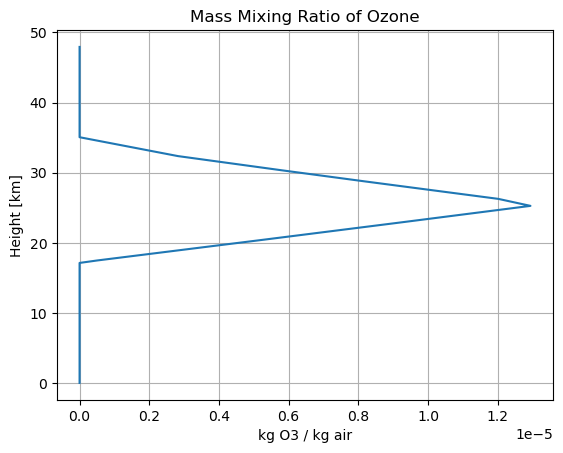

In [671]:
plt.plot(mmr_o3, z_layers / 1000)
plt.grid()
plt.xlabel("kg O3 / kg air")
plt.ylabel("Height [km]")
plt.title("Mass Mixing Ratio of Ozone")
# plt.plot(rho_o3,p_layers)

In [672]:
# plt.plot(tau_dz, z_layers[1:] / 1000)
# plt.grid()
# plt.xlabel("Optical Depth [Ozone]")
# plt.ylabel("Height [km]")
# plt.title("Differential Optical Depth of Ozone")
# # plt.plot(rho_o3,p_layers)

Text(0.5, 1.0, 'Total Optical Depth of Ozone (viewed from space)')

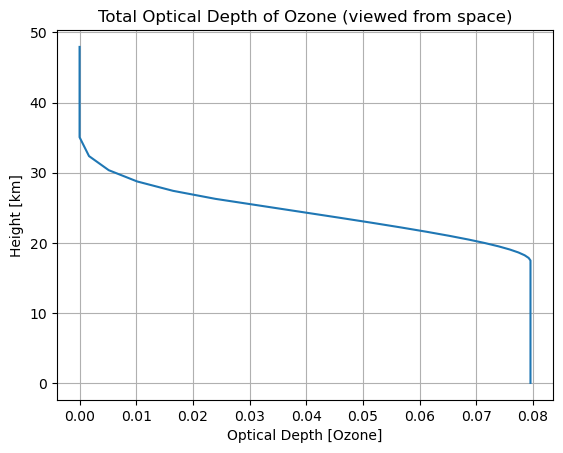

In [673]:
plt.plot(tau_oz, z_layers / 1000)
plt.grid()
plt.xlabel("Optical Depth [Ozone]")
plt.ylabel("Height [km]")
plt.title("Total Optical Depth of Ozone (viewed from space)")
# plt.plot(rho_o3,p_layers)

Text(0.5, 1.0, 'Transmissivity from space to atm layer')

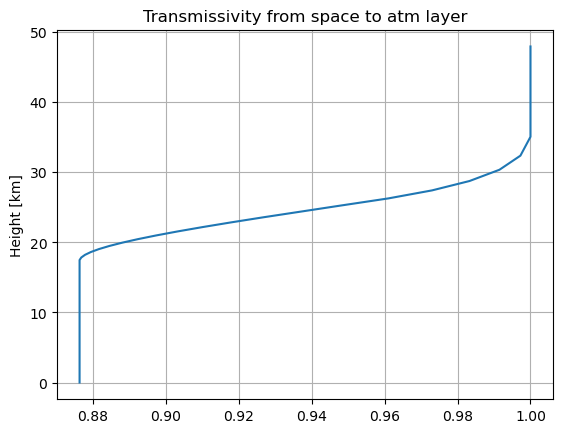

In [674]:
plt.plot(np.exp(-1.66 * tau_oz), z_layers / 1000)
plt.grid()
# plt.xlabel('Optical Depth [Ozone]')
plt.ylabel("Height [km]")
plt.title("Transmissivity from space to atm layer")
# plt.plot(rho_o3,p_layers)

Text(0.5, 1.0, 'Transmitted solar radiation from space to atm layer')

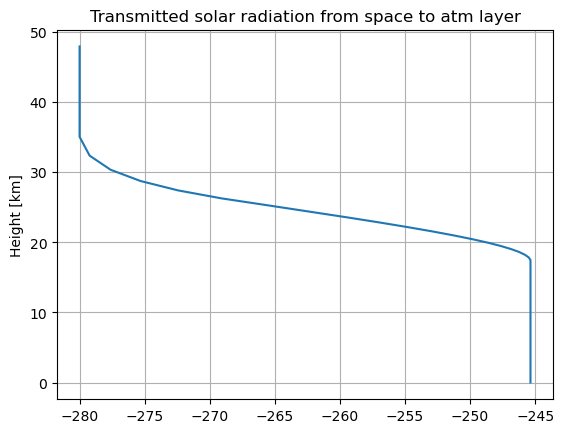

In [675]:
# transmitted solar radiation
plt.plot(transmitted_solar_rad[:-1], z_layers / 1000)
plt.grid()
# plt.xlabel('Optical Depth [Ozone]')
plt.ylabel("Height [km]")
plt.title("Transmitted solar radiation from space to atm layer")
# plt.plot(rho_o3,p_layers)

Text(0.5, 1.0, 'Absorbed solar radiation in each layer')

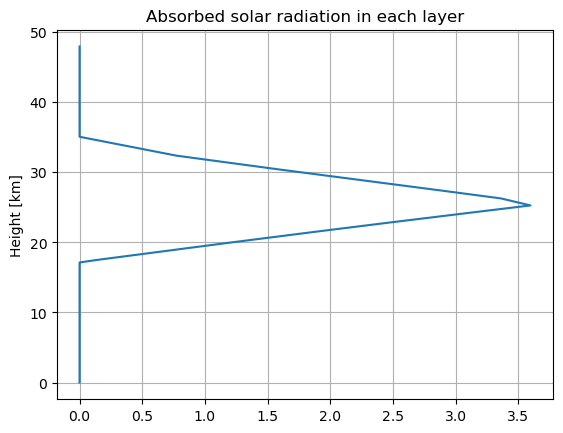

In [676]:
# transmitted solar radiation
plt.plot(absorbed_solar_rad, z_layers / 1000)
plt.grid()
# plt.xlabel('Optical Depth [Ozone]')
plt.ylabel("Height [km]")
plt.title("Absorbed solar radiation in each layer")
# plt.plot(rho_o3,p_layers)

In [677]:
# start from isothermal atmosphere
# calculate radiative equilibrium, dry convective eq, convective eq

In [678]:
f_lw_levels = net_terrestrial_flux_at_all_levels(  # calculate net terrestrial
    Ts,
    Ta_layers,  # radiation flux at all levels
    emissivity1xCO2_layers,
    trans1xCO2_levels_to_levels,
)
f_sw_levels = net_solar_flux_at_all_levels(z_levels = z_layers, toa_fsw = F_SW)
f_net_levels = f_lw_levels + f_sw_levels
F_div_layers = flux_divergence(f_net_levels, del_p) # divergence convention flipped for SW, since rad traveling down
flw_div_layers = flux_divergence(f_lw_levels, del_p)
fsw_div_layers = flux_divergence(f_sw_levels, del_p) # divergence convention flipped for SW, since rad traveling down

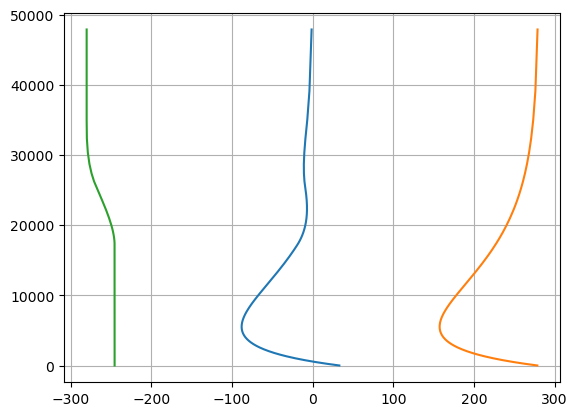

In [679]:
plt.plot(f_net_levels[:-1],z_layers,label='net')
plt.plot(f_lw_levels[:-1],z_layers,label='lw')
plt.plot(f_sw_levels[:-1],z_layers,label='sw')
plt.grid()

Text(0.5, 0, 'Flux Divergence [W/m^2/Pa]')

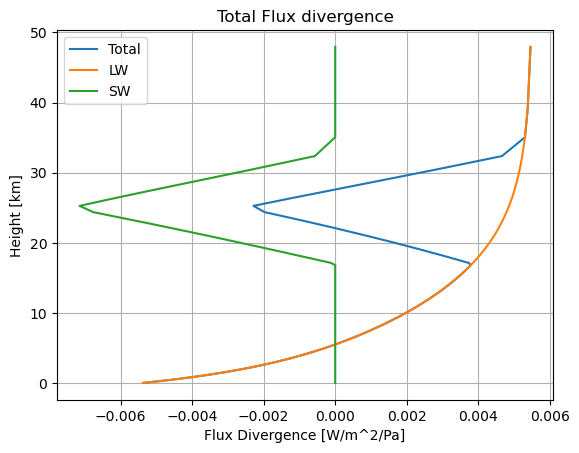

In [680]:
plt.title('Total Flux divergence')
plt.plot(F_div_layers,z_layers / 1000, label='Total')
plt.plot(flw_div_layers,z_layers / 1000, label='LW')
plt.plot(fsw_div_layers,z_layers / 1000, label='SW')
# plt.plot(flw_div_layers + fsw_div_layers, z_layers)
plt.grid()
plt.legend()
plt.ylabel('Height [km]')
plt.xlabel('Flux Divergence [W/m^2/Pa]')

In [655]:
def radiative_equilibrium_temperature_strat(
    Ts,
    T_layers,
    del_t,
    del_p,
    emissivity_layers,
    trans_levels_to_levels,
    z_layers,
    F_SW,
):
    T_layers_copy = copy.deepcopy(T_layers)  # avoid mutating temperature profile
    Ts_copy = copy.deepcopy(Ts)  # avoid mutating surface temperature
    s_layers = dry_static_energy(T_layers_copy, z_layers)  # calculate dry static energy
    max_F = 1.0  # max net energy flux at surface or TOA
    iteration_counter = 0  # counts number of iterations
    iteration_threshold = 0.1  # end iteration if max flux smaller
    while max_F > iteration_threshold:
        F_LW_levels = net_terrestrial_flux_at_all_levels(  # calculate net terrestrial
            Ts_copy,
            T_layers_copy,  # radiation flux at all levels
            emissivity_layers,
            trans_levels_to_levels,
        )
        f_sw_levels = net_solar_flux_at_all_levels(z_levels = z_layers, toa_fsw = F_SW)
        f_net_levels = F_LW_levels + f_sw_levels
        F_div_layers = flux_divergence(f_net_levels, del_p)  # divergence of net flux

        dsdt_layers = rate_of_energy_change(F_div_layers)  # rate of energy change
        ds_layers = dsdt_layers * del_t  # dry static energy change increment
        s_layers += ds_layers  # new dry static energy
        T_layers_copy = (
            T_from_dry_static_energy(  # get temperature from dry static energy
                s_layers, z_layers
            )
        )
        dTsdt = rate_of_surface_temperature_change(  # rate of surface T change
            f_net_levels[0]
        )
        dTs = dTsdt * del_t  # surface T change increment
        Ts_copy += dTs  # new surface temperature
        max_F = np.amax(  # maximum of either
            [
                np.abs(f_net_levels[0]),  # net energy flux at surface
                np.abs(f_net_levels[-1]),
            ]
        )  # or net energy flux at TOA
        iteration_counter += 1
        if iteration_counter % 100 == 0:
            print("Converging...")
    print("Done!")
    print(f"num itter: {iteration_counter}")
    return Ts_copy, T_layers_copy  # return radiative equilibrium temperature


In [656]:
Ts_rad1xCO2_strat, Ta_rad1xCO2_layers_strat = radiative_equilibrium_temperature_strat(
    Ts,
    Ta_layers,
    del_t,
    del_p,
    emissivity1xCO2_layers,
    trans1xCO2_levels_to_levels,
    z_layers,
    F_SW,
)

Converging...
Converging...
Done!
num itter: 235


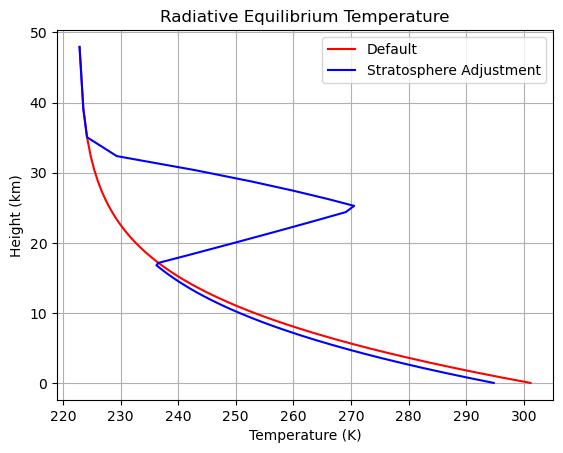

In [667]:
line_label = r"$\tau_0$ = " + str(tau1xCO2)
color = "tab:gray"
fig, ax = plt.subplots()
ax.plot(Ta_rad1xCO2_layers, z_layers / 1000.0, color='red', label='Default')
ax.plot(Ta_rad1xCO2_layers_strat, z_layers / 1000.0, color='blue', label='Stratosphere Adjustment')
# ax.set_ylim(0, 16)
ax.set(
    title="Radiative Equilibrium Temperature",
    xlabel="Temperature (K)",
    ylabel="Height (km)",
)
ax.legend()
ax.grid()

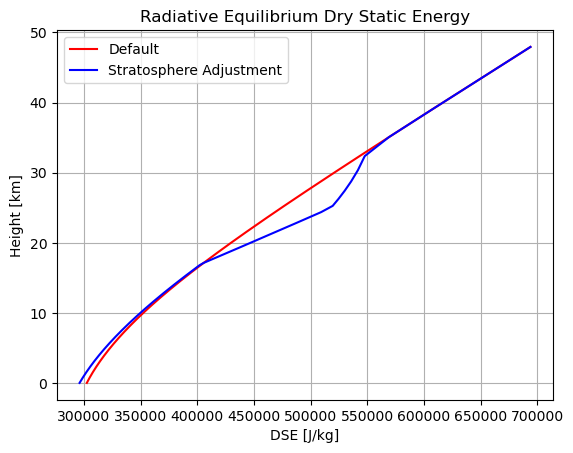

In [681]:
s_rad1xCO2_layers_strat = dry_static_energy(Ta_rad1xCO2_layers_strat, z_layers)

fig, ax = plt.subplots()
ax.plot(s_rad1xCO2_layers, z_layers / 1000.0, color='red', label='Default')
ax.plot(s_rad1xCO2_layers_strat, z_layers / 1000.0, color='blue', label='Stratosphere Adjustment')
# ax.set_ylim(0, 16)
ax.set(
    title="Radiative Equilibrium Dry Static Energy",
    xlabel="DSE [J/kg]",
    ylabel="Height [km]",
)
ax.legend()
ax.grid()